# The Carbon Market MRV Problem and Our Solution

Global warming is accelerating due to excess carbon emissions. To achieve **Net Zero**, countries and corporations are mandated to purchase carbon credits generated by projects that sequester carbon, such as planting mangroves (Blue Carbon). However, verifying exactly how much carbon these projects sequester is currently a massive bottleneck. It requires expensive manual teams on the ground to measure and report.

**Our solution automates MRV (Measurement, Reporting, and Verification)**. By leveraging satellite imagery and spatio-temporal deep learning, we eliminate the need for manual teams. While this notebook focuses on Mangroves (Blue Carbon), this architecture is built to scale across all forms of carbon (Green, White, etc.) globally.

# GEDI Missing Feature Imputation

In [ ]:
!pip install tensorflow

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/STAGE 1/S1_S2_GEDI_New_UAE_Monthly.csv')
df.head()

,latitude,longitude,VV_backscatter,VH_backscatter,VV_coherence,VH_coherence,date,B1,B2,B3,...,Highlight_Optimized_Natural_Color,True_color,GEDI_canopy_height_rh100,GEDI_canopy_height_rh98,GEDI_canopy_height_rh92,GEDI_elevation_lowestmode,GEDI_PAI,GEDI_FHD,GEDI_FCOVER,GEDI_biomass_Mg_ha
0,22.791063,54.246296,-24.314251,-31.478721,0.003703,0.000711,2021-01-01,755.0,1004.5,1856.5,...,3854.0,3854.0,NaN,NaN,NaN,NaN,0.275530,3.111608,0.128696,1.887865
1,22.791063,54.246296,-25.507535,-30.963398,0.002819,0.000801,2021-02-01,743.0,1055.0,1854.0,...,3866.0,3866.0,NaN,NaN,NaN,NaN,0.035450,1.304219,0.017569,1.171597
2,22.791063,54.246296,-25.626493,-31.186509,0.002737,0.000761,2021-03-01,693.5,1009.0,1882.0,...,3948.0,3948.0,NaN,NaN,NaN,NaN,0.166437,1.684900,0.079850,4.397345
3,22.791063,54.246296,-23.189345,-31.998171,0.004816,0.000642,2021-04-01,733.0,1026.0,1736.0,...,3804.0,3804.0,NaN,NaN,NaN,NaN,0.016584,1.592468,0.008258,4.079221
4,22.791063,54.246296,-22.832819,-25.969246,0.005209,0.002530,2021-05-01,756.5,1032.0,1804.0,...,3972.0,3972.0,NaN,NaN,NaN,NaN,0.023738,1.215489,0.011799,1.022177


In [ ]:
df.isnull().sum()

,0
latitude,0
longitude,0
VV_backscatter,2801
VH_backscatter,2801
VV_coherence,2801
VH_coherence,2801
date,0
B1,3994
B2,3995
B3,3995


In [ ]:
rh100_features=['VV_backscatter', 'VH_backscatter',
       'VV_coherence', 'VH_coherence', 'B1', 'B2', 'B3', 'B4', 'B5',
       'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'SCL', 'NDVI', 'NDWI',
       'NDSI', 'Moisture_index', 'SWIR', 'Scene_classification_map',
       'False_color', 'False_color_urban', 'Highlight_Optimized_Natural_Color',
       'True_color', 'GEDI_canopy_height_rh100']

rh98_features=['VV_backscatter', 'VH_backscatter',
       'VV_coherence', 'VH_coherence', 'B1', 'B2', 'B3', 'B4', 'B5',
       'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'SCL', 'NDVI', 'NDWI',
       'NDSI', 'Moisture_index', 'SWIR', 'Scene_classification_map',
       'False_color', 'False_color_urban', 'Highlight_Optimized_Natural_Color',
       'True_color', 'GEDI_canopy_height_rh98']

rh92_features=['VV_backscatter', 'VH_backscatter',
       'VV_coherence', 'VH_coherence', 'B1', 'B2', 'B3', 'B4', 'B5',
       'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'SCL', 'NDVI', 'NDWI',
       'NDSI', 'Moisture_index', 'SWIR', 'Scene_classification_map',
       'False_color', 'False_color_urban', 'Highlight_Optimized_Natural_Color',
       'True_color', 'GEDI_canopy_height_rh92']

elevation_features=['VV_backscatter', 'VH_backscatter',
       'VV_coherence', 'VH_coherence', 'B1', 'B2', 'B3', 'B4', 'B5',
       'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'SCL', 'NDVI', 'NDWI',
       'NDSI', 'Moisture_index', 'SWIR', 'Scene_classification_map',
       'False_color', 'False_color_urban', 'Highlight_Optimized_Natural_Color',
       'True_color', 'GEDI_elevation_lowestmode']

pai_features=['VV_backscatter', 'VH_backscatter',
       'VV_coherence', 'VH_coherence', 'B1', 'B2', 'B3', 'B4', 'B5',
       'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'SCL', 'NDVI', 'NDWI',
       'NDSI', 'Moisture_index', 'SWIR', 'Scene_classification_map',
       'False_color', 'False_color_urban', 'Highlight_Optimized_Natural_Color',
       'True_color', 'GEDI_PAI']

fhd_features=['VV_backscatter', 'VH_backscatter',
       'VV_coherence', 'VH_coherence','B1', 'B2', 'B3', 'B4', 'B5',
       'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'SCL', 'NDVI', 'NDWI',
       'NDSI', 'Moisture_index', 'SWIR', 'Scene_classification_map',
       'False_color', 'False_color_urban', 'Highlight_Optimized_Natural_Color',
       'True_color', 'GEDI_FHD']

fcover_features=['VV_backscatter', 'VH_backscatter',
       'VV_coherence', 'VH_coherence','B1', 'B2', 'B3', 'B4', 'B5',
       'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'SCL', 'NDVI', 'NDWI',
       'NDSI', 'Moisture_index', 'SWIR', 'Scene_classification_map',
       'False_color', 'False_color_urban', 'Highlight_Optimized_Natural_Color',
       'True_color', 'GEDI_FCOVER']

biomass_features=['VV_backscatter', 'VH_backscatter',
       'VV_coherence', 'VH_coherence','B1', 'B2', 'B3', 'B4', 'B5',
       'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'SCL', 'NDVI', 'NDWI',
       'NDSI', 'Moisture_index', 'SWIR', 'Scene_classification_map',
       'False_color', 'False_color_urban', 'Highlight_Optimized_Natural_Color',
       'True_color','GEDI_biomass_Mg_ha']

In [ ]:
from sklearn.impute import SimpleImputer

columns_to_impute = [
    'VV_backscatter', 'VH_backscatter', 'VV_coherence', 'VH_coherence',
    'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12',
    'SCL', 'NDVI', 'NDWI', 'NDSI', 'Moisture_index', 'SWIR',
    'Scene_classification_map', 'False_color', 'False_color_urban',
    'Highlight_Optimized_Natural_Color', 'True_color'
]

imputer = SimpleImputer(strategy='median')

for col in columns_to_impute:
    if col in df.columns:
        df[col] = imputer.fit_transform(df[[col]])

print('Missing values in df after imputation:')
print(df[columns_to_impute].isnull().sum().sum())

Missing values in df after imputation:
0


In [ ]:
df_available_rh100=df[df['GEDI_canopy_height_rh100'].notna()][rh100_features]
df_available_rh98=df[df['GEDI_canopy_height_rh98'].notna()][rh98_features]
df_available_rh92=df[df['GEDI_canopy_height_rh92'].notna()][rh92_features]
df_available_elevation=df[df['GEDI_elevation_lowestmode'].notna()][elevation_features]
df_available_pai=df[df['GEDI_PAI'].notna()][pai_features]
df_available_fhd=df[df['GEDI_FHD'].notna()][fhd_features]
df_available_fcover=df[df['GEDI_FCOVER'].notna()][fcover_features]
df_available_biomass=df[df['GEDI_biomass_Mg_ha'].notna()][biomass_features]

print(df_available_rh100.shape)
print(df_available_rh98.shape)
print(df_available_rh92.shape)
print(df_available_elevation.shape)
print(df_available_pai.shape)
print(df_available_fhd.shape)
print(df_available_fcover.shape)
print(df_available_biomass.shape)


(119424, 28)
(119424, 28)
(119424, 28)
(119424, 28)
(141816, 28)
(141816, 28)
(141816, 28)
(145548, 28)


In [ ]:
rh100_x=df_available_rh100.drop('GEDI_canopy_height_rh100',axis=1)
rh100_y=df_available_rh100['GEDI_canopy_height_rh100']

rh98_x=df_available_rh98.drop('GEDI_canopy_height_rh98',axis=1)
rh98_y=df_available_rh98['GEDI_canopy_height_rh98']

rh92_x=df_available_rh92.drop('GEDI_canopy_height_rh92',axis=1)
rh92_y=df_available_rh92['GEDI_canopy_height_rh92']

elevation_x=df_available_elevation.drop('GEDI_elevation_lowestmode',axis=1)
elevation_y=df_available_elevation['GEDI_elevation_lowestmode']

pai_x=df_available_pai.drop('GEDI_PAI',axis=1)
pai_y=df_available_pai['GEDI_PAI']

fhd_x=df_available_fhd.drop('GEDI_FHD',axis=1)
fhd_y=df_available_fhd['GEDI_FHD']

fcover_x=df_available_fcover.drop('GEDI_FCOVER',axis=1)
fcover_y=df_available_fcover['GEDI_FCOVER']

biomass_x=df_available_biomass.drop('GEDI_biomass_Mg_ha',axis=1)
biomass_y=df_available_biomass['GEDI_biomass_Mg_ha']

print(rh100_x.shape)
print(rh100_y.shape)
print(rh98_x.shape)
print(rh98_y.shape)
print(rh92_x.shape)
print(rh92_y.shape)
print(elevation_x.shape)
print(elevation_y.shape)
print(pai_x.shape)
print(pai_y.shape)
print(fhd_x.shape)
print(fhd_y.shape)
print(fcover_x.shape)
print(fcover_y.shape)
print(biomass_x.shape)
print(biomass_y.shape)

(119424, 27)
(119424,)
(119424, 27)
(119424,)
(119424, 27)
(119424,)
(119424, 27)
(119424,)
(141816, 27)
(141816,)
(141816, 27)
(141816,)
(141816, 27)
(141816,)
(145548, 27)
(145548,)


In [ ]:
print(rh100_x.isnull().sum())
print(rh98_x.isnull().sum())
print(rh92_x.isnull().sum())
print(elevation_x.isnull().sum())
print(pai_x.isnull().sum())
print(fhd_x.isnull().sum())
print(fcover_x.isnull().sum())
print(biomass_x.isnull().sum())

print(rh100_y.isnull().sum())
print(rh98_y.isnull().sum())
print(rh92_y.isnull().sum())
print(elevation_y.isnull().sum())
print(pai_y.isnull().sum())
print(fhd_y.isnull().sum())
print(fcover_y.isnull().sum())
print(biomass_y.isnull().sum())

VV_backscatter                       0
VH_backscatter                       0
VV_coherence                         0
VH_coherence                         0
B1                                   0
B2                                   0
B3                                   0
B4                                   0
B5                                   0
B6                                   0
B7                                   0
B8                                   0
B8A                                  0
B9                                   0
B11                                  0
B12                                  0
SCL                                  0
NDVI                                 0
NDWI                                 0
NDSI                                 0
Moisture_index                       0
SWIR                                 0
Scene_classification_map             0
False_color                          0
False_color_urban                    0
Highlight_Optimized_Natur

In [ ]:
X_train_rh100, X_test_rh100, y_train_rh100, y_test_rh100=train_test_split(rh100_x,rh100_y,test_size=0.2,random_state=42)
X_train_rh98, X_test_rh98, y_train_rh98, y_test_rh98=train_test_split(rh98_x,rh98_y,test_size=0.2,random_state=42)
X_train_rh92, X_test_rh92, y_train_rh92, y_test_rh92=train_test_split(rh92_x,rh92_y,test_size=0.2,random_state=42)
X_train_elevation, X_test_elevation, y_train_elevation, y_test_elevation=train_test_split(elevation_x,elevation_y,test_size=0.2,random_state=42)
X_train_pai, X_test_pai, y_train_pai, y_test_pai=train_test_split(pai_x,pai_y,test_size=0.2,random_state=42)
X_train_fhd, X_test_fhd, y_train_fhd, y_test_fhd=train_test_split(fhd_x,fhd_y,test_size=0.2,random_state=42)
X_train_fcover, X_test_fcover, y_train_fcover, y_test_fcover=train_test_split(fcover_x,fcover_y,test_size=0.2,random_state=42)
X_train_biomass, X_test_biomass, y_train_biomass, y_test_biomass=train_test_split(biomass_x,biomass_y,test_size=0.2,random_state=42)

# RH100 Imputation Using Model

In [ ]:
model_rh100 = Sequential()

# First hidden layer
model_rh100.add(Dense(512, activation='relu', input_shape=(X_train_rh100.shape[1],)))
model_rh100.add(BatchNormalization())
model_rh100.add(Dropout(0.4))
# Second hidden layer
model_rh100.add(Dense(256, activation='relu'))
model_rh100.add(BatchNormalization())
model_rh100.add(Dropout(0.3))
# Third hidden layer
model_rh100.add(Dense(128, activation='relu'))
model_rh100.add(BatchNormalization())
model_rh100.add(Dropout(0.2))

# Output layer for regression
model_rh100.add(Dense(1, activation='linear'))

model_rh100.compile(optimizer='adam', loss='mean_squared_error', metrics=['mse'])
model_rh100.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,273 (712.00 KB)

 Trainable params: 180,481 (705.00 KB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
#model_rh100 training with EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

history = model_rh100.fit(
    X_train_rh100,
    y_train_rh100,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 12.8182 - mse: 12.8182 - val_loss: 11.5094 - val_mse: 11.5094
Epoch 2/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 10.3733 - mse: 10.3733 - val_loss: 11.3908 - val_mse: 11.3908
Epoch 3/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 10.8118 - mse: 10.8118 - val_loss: 11.5717 - val_mse: 11.5717
Epoch 4/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 10.1613 - mse: 10.1613 - val_loss: 11.6505 - val_mse: 11.6505
Epoch 5/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 10.6749 - mse: 10.6749 - val_loss: 13.2303 - val_mse: 13.2303
Epoch 6/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 10.2741 - mse: 10.2741 - val_loss: 11.5364 - val_mse: 11.5364
Epoch 7/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 11.0353 - mse: 11.0353 - val_loss: 36.6006 - val_mse: 36.6006
Epoch 8/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 10.7947 - mse: 10.7947 - val_loss: 13.8485 - val_mse: 13.8485


In [ ]:
missing_rh100_mask = df['GEDI_canopy_height_rh100'].isna()
print("Number of rows with missing GEDI_canopy_height_rh100 values:", missing_rh100_mask.sum())
rh100_input_features = rh100_x.columns.tolist()
print("rh100 input features:", rh100_input_features)
X_predict_missing_rh100 = df[missing_rh100_mask][rh100_input_features]
print("Shape of X_predict_missing_rh100:", X_predict_missing_rh100.shape)
print("First 5 rows of X_predict_missing_rh100:\n", X_predict_missing_rh100.head())
predicted_rh100_values = model_rh100.predict(X_predict_missing_rh100).flatten()
print("Shape of predicted_rh100_values:", predicted_rh100_values.shape)
print("First 5 predicted GEDI_canopy_height_rh100 values:", predicted_rh100_values[:5])
df.loc[missing_rh100_mask, 'GEDI_canopy_height_rh100'] = predicted_rh100_values
print("Number of missing GEDI_canopy_height_rh100 values after imputation:", df['GEDI_canopy_height_rh100'].isnull().sum())

Number of rows with missing GEDI_canopy_height_rh100 values: 125186
rh100 input features: ['VV_backscatter', 'VH_backscatter', 'VV_coherence', 'VH_coherence', 'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'SCL', 'NDVI', 'NDWI', 'NDSI', 'Moisture_index', 'SWIR', 'Scene_classification_map', 'False_color', 'False_color_urban', 'Highlight_Optimized_Natural_Color', 'True_color']
Shape of X_predict_missing_rh100: (125186, 27)
First 5 rows of X_predict_missing_rh100:
    VV_backscatter  VH_backscatter  VV_coherence  VH_coherence     B1      B2  \
0      -24.314251      -31.478721      0.003703      0.000711  755.0  1004.5   
1      -25.507535      -30.963398      0.002819      0.000801  743.0  1055.0   
2      -25.626493      -31.186509      0.002737      0.000761  693.5  1009.0   
3      -23.189345      -31.998171      0.004816      0.000642  733.0  1026.0   
4      -22.832819      -25.969246      0.005209      0.002530  756.5  1032.0   

       B3      B4      B

In [ ]:
import tensorflow as tf

save_path = '/content/drive/MyDrive/STAGE 1/Model_GEDI_RH100.h5'
model_rh100.save(save_path)
print(f"model_rh98 saved successfully to {save_path}")

model_pai saved successfully to /content/drive/MyDrive/STAGE 1/Model_GEDI_RH100.h5


# RH98 Imputation Using Model

In [ ]:
model_rh98 = Sequential()

# First hidden layer
model_rh98.add(Dense(512, activation='relu', input_shape=(X_train_rh98.shape[1],)))
model_rh98.add(BatchNormalization())
model_rh98.add(Dropout(0.4))
# Second hidden layer
model_rh98.add(Dense(256, activation='relu'))
model_rh98.add(BatchNormalization())
model_rh98.add(Dropout(0.3))
# Third hidden layer
model_rh98.add(Dense(128, activation='relu'))
model_rh98.add(BatchNormalization())
model_rh98.add(Dropout(0.2))

# Output layer for regression
model_rh98.add(Dense(1, activation='linear'))

model_rh98.compile(optimizer='adam', loss='mean_squared_error', metrics=['mse'])
model_rh98.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,273 (712.00 KB)

 Trainable params: 180,481 (705.00 KB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
#model_rh98 training with EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

history = model_rh98.fit(
    X_train_rh98,
    y_train_rh98,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 10.7210 - mse: 10.7210 - val_loss: 10.0373 - val_mse: 10.0373
Epoch 2/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 8.5671 - mse: 8.5671 - val_loss: 10.1158 - val_mse: 10.1158
Epoch 3/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 8.8698 - mse: 8.8698 - val_loss: 9.9709 - val_mse: 9.9709
Epoch 4/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 8.8856 - mse: 8.8856 - val_loss: 10.2679 - val_mse: 10.2679
Epoch 5/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 8.9590 - mse: 8.9590 - val_loss: 10.0545 - val_mse: 10.0545
Epoch 6/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 8.4548 - mse: 8.4548 - val_loss: 10.9315 - val_mse: 10.9315
Epoch 7/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 8.8187 - mse: 8.8187 - val_loss: 10.3595 - val_mse: 10.3595
Epoch 8/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 9.1068 - mse: 9.1068 - val_loss: 10.8674 - val_mse: 10.8674
Epoch 9/50
2389/

In [ ]:
missing_rh98_mask = df['GEDI_canopy_height_rh98'].isna()
print("Number of rows with missing GEDI_canopy_height_rh98 values:", missing_rh98_mask.sum())
rh98_input_features = rh98_x.columns.tolist()
print("rh98 input features:", rh98_input_features)
X_predict_missing_rh98 = df[missing_rh98_mask][rh98_input_features]
print("Shape of X_predict_missing_rh98:", X_predict_missing_rh98.shape)
print("First 5 rows of X_predict_missing_rh98:\n", X_predict_missing_rh98.head())
predicted_rh98_values = model_rh98.predict(X_predict_missing_rh98).flatten()
print("Shape of predicted_rh98_values:", predicted_rh98_values.shape)
print("First 5 predicted GEDI_canopy_height_rh98 values:", predicted_rh98_values[:5])
df.loc[missing_rh98_mask, 'GEDI_canopy_height_rh98'] = predicted_rh98_values
print("Number of missing GEDI_canopy_height_rh98 values after imputation:", df['GEDI_canopy_height_rh98'].isnull().sum())

Number of rows with missing GEDI_canopy_height_rh98 values: 125186
rh98 input features: ['VV_backscatter', 'VH_backscatter', 'VV_coherence', 'VH_coherence', 'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'SCL', 'NDVI', 'NDWI', 'NDSI', 'Moisture_index', 'SWIR', 'Scene_classification_map', 'False_color', 'False_color_urban', 'Highlight_Optimized_Natural_Color', 'True_color']
Shape of X_predict_missing_rh98: (125186, 27)
First 5 rows of X_predict_missing_rh98:
    VV_backscatter  VH_backscatter  VV_coherence  VH_coherence     B1      B2  \
0      -24.314251      -31.478721      0.003703      0.000711  755.0  1004.5   
1      -25.507535      -30.963398      0.002819      0.000801  743.0  1055.0   
2      -25.626493      -31.186509      0.002737      0.000761  693.5  1009.0   
3      -23.189345      -31.998171      0.004816      0.000642  733.0  1026.0   
4      -22.832819      -25.969246      0.005209      0.002530  756.5  1032.0   

       B3      B4      B5   

In [ ]:
import tensorflow as tf

save_path = '/content/drive/MyDrive/STAGE 1/Model_GEDI_RH98.h5'
model_rh98.save(save_path)
print(f"model_rh98 saved successfully to {save_path}")

model_rh98 saved successfully to /content/drive/MyDrive/STAGE 1/Model_GEDI_RH98.h5


# RH92 Imputation Using Model

In [ ]:
model_rh92 = Sequential()

# First hidden layer
model_rh92.add(Dense(512, activation='relu', input_shape=(X_train_rh92.shape[1],)))
model_rh92.add(BatchNormalization())
model_rh92.add(Dropout(0.4))
# Second hidden layer
model_rh92.add(Dense(256, activation='relu'))
model_rh92.add(BatchNormalization())
model_rh92.add(Dropout(0.3))
# Third hidden layer
model_rh92.add(Dense(128, activation='relu'))
model_rh92.add(BatchNormalization())
model_rh92.add(Dropout(0.2))

# Output layer for regression
model_rh92.add(Dense(1, activation='linear'))

model_rh92.compile(optimizer='adam', loss='mean_squared_error', metrics=['mse'])
model_rh92.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 512)            │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,273 (712.00 KB)

 Trainable params: 180,481 (705.00 KB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
#model_rh92 training with EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

history = model_rh92.fit(
    X_train_rh92,
    y_train_rh92,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 7.8696 - mse: 7.8696 - val_loss: 7.9160 - val_mse: 7.9160
Epoch 2/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 7.5675 - mse: 7.5675 - val_loss: 7.8931 - val_mse: 7.8931
Epoch 3/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 7.0971 - mse: 7.0971 - val_loss: 7.9267 - val_mse: 7.9267
Epoch 4/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 7.3222 - mse: 7.3222 - val_loss: 8.0274 - val_mse: 8.0274
Epoch 5/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 7.5147 - mse: 7.5147 - val_loss: 7.8977 - val_mse: 7.8977
Epoch 6/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 6.5708 - mse: 6.5708 - val_loss: 7.9439 - val_mse: 7.9439
Epoch 7/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 6.5644 - mse: 6.5644 - val_loss: 8.3508 - val_mse: 8.3508
Epoch 8/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 6.8140 - mse: 6.8140 - val_loss: 8.0365 - val_mse: 8.0365
Epoch 9/50
2389/2389 ━━━━━━━━━━━

In [ ]:
missing_rh92_mask = df['GEDI_canopy_height_rh92'].isna()
print("Number of rows with missing GEDI_canopy_height_rh92 values:", missing_rh92_mask.sum())
rh92_input_features = rh92_x.columns.tolist()
print("rh92 input features:", rh92_input_features)
X_predict_missing_rh92 = df[missing_rh92_mask][rh92_input_features]
print("Shape of X_predict_missing_rh92:", X_predict_missing_rh92.shape)
print("First 5 rows of X_predict_missing_rh92:\n", X_predict_missing_rh92.head())
predicted_rh92_values = model_rh92.predict(X_predict_missing_rh92).flatten()
print("Shape of predicted_rh92_values:", predicted_rh92_values.shape)
print("First 5 predicted GEDI_canopy_height_rh92 values:", predicted_rh92_values[:5])
df.loc[missing_rh92_mask, 'GEDI_canopy_height_rh92'] = predicted_rh92_values
print("Number of missing GEDI_canopy_height_rh92 values after imputation:", df['GEDI_canopy_height_rh92'].isnull().sum())

Number of rows with missing GEDI_canopy_height_rh92 values: 125186
rh92 input features: ['VV_backscatter', 'VH_backscatter', 'VV_coherence', 'VH_coherence', 'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'SCL', 'NDVI', 'NDWI', 'NDSI', 'Moisture_index', 'SWIR', 'Scene_classification_map', 'False_color', 'False_color_urban', 'Highlight_Optimized_Natural_Color', 'True_color']
Shape of X_predict_missing_rh92: (125186, 27)
First 5 rows of X_predict_missing_rh92:
    VV_backscatter  VH_backscatter  VV_coherence  VH_coherence     B1      B2  \
0      -24.314251      -31.478721      0.003703      0.000711  755.0  1004.5   
1      -25.507535      -30.963398      0.002819      0.000801  743.0  1055.0   
2      -25.626493      -31.186509      0.002737      0.000761  693.5  1009.0   
3      -23.189345      -31.998171      0.004816      0.000642  733.0  1026.0   
4      -22.832819      -25.969246      0.005209      0.002530  756.5  1032.0   

       B3      B4      B5   

In [ ]:
import tensorflow as tf

save_path = '/content/drive/MyDrive/STAGE 1/Model_GEDI_RH92.h5'
model_rh92.save(save_path)
print(f"model_rh92 saved successfully to {save_path}")

model_rh92 saved successfully to /content/drive/MyDrive/STAGE 1/Model_GEDI_RH92.h5


# ELEVATION Imputation Using Model

In [ ]:
model_elevation = Sequential()

# First hidden layer
model_elevation.add(Dense(512, activation='relu', input_shape=(X_train_elevation.shape[1],)))
model_elevation.add(BatchNormalization())
model_elevation.add(Dropout(0.4))
# Second hidden layer
model_elevation.add(Dense(256, activation='relu'))
model_elevation.add(BatchNormalization())
model_elevation.add(Dropout(0.3))
# Third hidden layer
model_elevation.add(Dense(128, activation='relu'))
model_elevation.add(BatchNormalization())
model_elevation.add(Dropout(0.2))

# Output layer for regression
model_elevation.add(Dense(1, activation='linear'))

model_elevation.compile(optimizer='adam', loss='mean_squared_error', metrics=['mse'])
model_elevation.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 512)            │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,273 (712.00 KB)

 Trainable params: 180,481 (705.00 KB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
#model_elevation training with EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

history = model_elevation.fit(
    X_train_elevation,
    y_train_elevation,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 4115617.7500 - mse: 4115617.7500 - val_loss: 3660981.2500 - val_mse: 3660981.2500
Epoch 2/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 3597820.0000 - mse: 3597820.0000 - val_loss: 7727402.0000 - val_mse: 7727402.0000
Epoch 3/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 3563158.7500 - mse: 3563158.7500 - val_loss: 11141567.0000 - val_mse: 11141567.0000
Epoch 4/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 3554336.7500 - mse: 3554336.7500 - val_loss: 3847066.5000 - val_mse: 3847066.5000
Epoch 5/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 3609427.2500 - mse: 3609427.2500 - val_loss: 376854176.0000 - val_mse: 376854176.0000
Epoch 6/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 3599929.2500 - mse: 3599929.2500 - val_loss: 5707581440.0000 - val_mse: 5707581440.0000
Epoch 7/50
2389/2389 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 3507489.2500 - mse: 3507489.2500 - val_loss: 282758944.

In [ ]:
missing_elevation_mask = df['GEDI_elevation_lowestmode'].isna()
print("Number of rows with missing GEDI_elevation_lowestmode values:", missing_elevation_mask.sum())
elevation_input_features = elevation_x.columns.tolist()
print("elevation input features:", elevation_input_features)
X_predict_missing_elevation = df[missing_elevation_mask][elevation_input_features]
print("Shape of X_predict_missing_elevation:", X_predict_missing_elevation.shape)
print("First 5 rows of X_predict_missing_elevation:\n", X_predict_missing_elevation.head())
predicted_elevation_values = model_elevation.predict(X_predict_missing_elevation).flatten()
print("Shape of predicted_elevation_values:", predicted_elevation_values.shape)
print("First 5 predicted GEDI_elevation_lowestmode values:", predicted_elevation_values[:5])
df.loc[missing_elevation_mask, 'GEDI_elevation_lowestmode'] = predicted_elevation_values
print("Number of missing GEDI_elevation_lowestmode values after imputation:", df['GEDI_elevation_lowestmode'].isnull().sum())

Number of rows with missing GEDI_elevation_lowestmode values: 125186
elevation input features: ['VV_backscatter', 'VH_backscatter', 'VV_coherence', 'VH_coherence', 'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'SCL', 'NDVI', 'NDWI', 'NDSI', 'Moisture_index', 'SWIR', 'Scene_classification_map', 'False_color', 'False_color_urban', 'Highlight_Optimized_Natural_Color', 'True_color']
Shape of X_predict_missing_elevation: (125186, 27)
First 5 rows of X_predict_missing_elevation:
    VV_backscatter  VH_backscatter  VV_coherence  VH_coherence     B1      B2  \
0      -24.314251      -31.478721      0.003703      0.000711  755.0  1004.5   
1      -25.507535      -30.963398      0.002819      0.000801  743.0  1055.0   
2      -25.626493      -31.186509      0.002737      0.000761  693.5  1009.0   
3      -23.189345      -31.998171      0.004816      0.000642  733.0  1026.0   
4      -22.832819      -25.969246      0.005209      0.002530  756.5  1032.0   

       B3  

In [ ]:
import tensorflow as tf

save_path = '/content/drive/MyDrive/STAGE 1/Model_GEDI_ELEVATION.h5'
model_elevation.save(save_path)
print(f"model_elevation saved successfully to {save_path}")

model_elevation saved successfully to /content/drive/MyDrive/STAGE 1/Model_GEDI_ELEVATION.h5


# PAI Imputation Using Model

In [ ]:
model_pai = Sequential()

# First hidden layer
model_pai.add(Dense(512, activation='relu', input_shape=(X_train_pai.shape[1],)))
model_pai.add(BatchNormalization())
model_pai.add(Dropout(0.4))
# Second hidden layer
model_pai.add(Dense(256, activation='relu'))
model_pai.add(BatchNormalization())
model_pai.add(Dropout(0.3))
# Third hidden layer
model_pai.add(Dense(128, activation='relu'))
model_pai.add(BatchNormalization())
model_pai.add(Dropout(0.2))

# Output layer for regression
model_pai.add(Dense(1, activation='linear'))

model_pai.compile(optimizer='adam', loss='mean_squared_error', metrics=['mse'])
model_pai.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 512)            │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,273 (712.00 KB)

 Trainable params: 180,481 (705.00 KB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
#model_pai training with EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

history = model_pai.fit(
    X_train_pai,
    y_train_pai,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/50
2837/2837 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 0.5003 - mse: 0.5003 - val_loss: 0.1675 - val_mse: 0.1675
Epoch 2/50
2837/2837 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 0.1739 - mse: 0.1739 - val_loss: 0.1713 - val_mse: 0.1713
Epoch 3/50
2837/2837 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 0.1788 - mse: 0.1788 - val_loss: 0.1657 - val_mse: 0.1657
Epoch 4/50
2837/2837 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.1778 - mse: 0.1778 - val_loss: 0.1671 - val_mse: 0.1671
Epoch 5/50
2837/2837 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 0.1834 - mse: 0.1834 - val_loss: 0.1692 - val_mse: 0.1692
Epoch 6/50
2837/2837 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 0.1764 - mse: 0.1764 - val_loss: 0.1674 - val_mse: 0.1674
Epoch 7/50
2837/2837 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.1835 - mse: 0.1835 - val_loss: 0.1658 - val_mse: 0.1658
Epoch 8/50
2837/2837 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 0.1829 - mse: 0.1829 - val_loss: 0.2034 - val_mse: 0.2034
Epoch 9/50
2837/2837 ━━━━━━━━━━━

In [ ]:
missing_pai_mask = df['GEDI_PAI'].isna()
print("Number of rows with missing GEDI_PAI values:", missing_pai_mask.sum())
pai_input_features = pai_x.columns.tolist()
print("PAI input features:", pai_input_features)
X_predict_missing_pai = df[missing_pai_mask][pai_input_features]
print("Shape of X_predict_missing_pai:", X_predict_missing_pai.shape)
print("First 5 rows of X_predict_missing_pai:\n", X_predict_missing_pai.head())
predicted_pai_values = model_pai.predict(X_predict_missing_pai).flatten()
print("Shape of predicted_pai_values:", predicted_pai_values.shape)
print("First 5 predicted GEDI_PAI values:", predicted_pai_values[:5])
df.loc[missing_pai_mask, 'GEDI_PAI'] = predicted_pai_values
print("Number of missing GEDI_PAI values after imputation:", df['GEDI_PAI'].isnull().sum())

Number of rows with missing GEDI_PAI values: 102794
PAI input features: ['VV_backscatter', 'VH_backscatter', 'VV_coherence', 'VH_coherence', 'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'SCL', 'NDVI', 'NDWI', 'NDSI', 'Moisture_index', 'SWIR', 'Scene_classification_map', 'False_color', 'False_color_urban', 'Highlight_Optimized_Natural_Color', 'True_color']
Shape of X_predict_missing_pai: (102794, 27)
First 5 rows of X_predict_missing_pai:
     VV_backscatter  VH_backscatter  VV_coherence  VH_coherence     B1      B2  \
27      -23.091339      -31.609378      0.004941      0.000698  806.0  1097.0   
28      -23.097345      -30.866525      0.004901      0.000819  629.5  1009.0   
29      -25.598752      -31.068139      0.002795      0.000785  686.5   910.0   
30      -25.295260      -30.568413      0.002954      0.000877  472.0   874.0   
31      -23.954406      -47.807456      0.004112      0.000017  702.5   989.0   

        B3      B4      B5      B6  ... 

# FHD Imputation Using Model

In [ ]:
import tensorflow as tf

save_path = '/content/drive/MyDrive/STAGE 1/Model_GEDI_PAI.h5'
model_pai.save(save_path)
print(f"model_pai saved successfully to {save_path}")

model_pai saved successfully to /content/drive/MyDrive/STAGE 1/Model_GEDI_PAI.h5


In [ ]:
model_fhd = Sequential()

# First hidden layer
model_fhd.add(Dense(512, activation='relu', input_shape=(X_train_fhd.shape[1],)))
model_fhd.add(BatchNormalization())
model_fhd.add(Dropout(0.4))
# Second hidden layer
model_fhd.add(Dense(256, activation='relu'))
model_fhd.add(BatchNormalization())
model_fhd.add(Dropout(0.3))
# Third hidden layer
model_fhd.add(Dense(128, activation='relu'))
model_fhd.add(BatchNormalization())
model_fhd.add(Dropout(0.2))

# Output layer for regression
model_fhd.add(Dense(1, activation='linear'))

model_fhd.compile(optimizer='adam', loss='mean_squared_error', metrics=['mse'])
model_fhd.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 512)            │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,273 (712.00 KB)

 Trainable params: 180,481 (705.00 KB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
#model_fhd training with EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

history = model_fhd.fit(
    X_train_fhd,
    y_train_fhd,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/50
2837/2837 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 0.5624 - mse: 0.5624 - val_loss: 0.1362 - val_mse: 0.1362
Epoch 2/50
2837/2837 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.1450 - mse: 0.1450 - val_loss: 0.1327 - val_mse: 0.1327
Epoch 3/50
2837/2837 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - loss: 0.1396 - mse: 0.1396 - val_loss: 0.1322 - val_mse: 0.1322
Epoch 4/50
2837/2837 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 0.1387 - mse: 0.1387 - val_loss: 0.1315 - val_mse: 0.1315
Epoch 5/50
2837/2837 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.1352 - mse: 0.1352 - val_loss: 0.1360 - val_mse: 0.1360
Epoch 6/50
2837/2837 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.1372 - mse: 0.1372 - val_loss: 0.1370 - val_mse: 0.1370
Epoch 7/50
2837/2837 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 0.1349 - mse: 0.1349 - val_loss: 0.1318 - val_mse: 0.1318
Epoch 8/50
2837/2837 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 0.1341 - mse: 0.1341 - val_loss: 0.7893 - val_mse: 0.7893
Epoch 9/50
2837/2837 ━━━━━━━━━━━

In [ ]:
missing_fhd_mask = df['GEDI_FHD'].isna()
print("Number of rows with missing GEDI_FHD values:", missing_fhd_mask.sum())
fhd_input_features = fhd_x.columns.tolist()
print("fhd input features:", fhd_input_features)
X_predict_missing_fhd = df[missing_fhd_mask][fhd_input_features]
print("Shape of X_predict_missing_fhd:", X_predict_missing_fhd.shape)
print("First 5 rows of X_predict_missing_fhd:\n", X_predict_missing_fhd.head())
predicted_fhd_values = model_fhd.predict(X_predict_missing_fhd).flatten()
print("Shape of predicted_fhd_values:", predicted_fhd_values.shape)
print("First 5 predicted GEDI_FHD values:", predicted_fhd_values[:5])
df.loc[missing_fhd_mask, 'GEDI_FHD'] = predicted_fhd_values
print("Number of missing GEDI_FHD values after imputation:", df['GEDI_FHD'].isnull().sum())

Number of rows with missing GEDI_FHD values: 102794
fhd input features: ['VV_backscatter', 'VH_backscatter', 'VV_coherence', 'VH_coherence', 'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'SCL', 'NDVI', 'NDWI', 'NDSI', 'Moisture_index', 'SWIR', 'Scene_classification_map', 'False_color', 'False_color_urban', 'Highlight_Optimized_Natural_Color', 'True_color']
Shape of X_predict_missing_fhd: (102794, 27)
First 5 rows of X_predict_missing_fhd:
     VV_backscatter  VH_backscatter  VV_coherence  VH_coherence     B1      B2  \
27      -23.091339      -31.609378      0.004941      0.000698  806.0  1097.0   
28      -23.097345      -30.866525      0.004901      0.000819  629.5  1009.0   
29      -25.598752      -31.068139      0.002795      0.000785  686.5   910.0   
30      -25.295260      -30.568413      0.002954      0.000877  472.0   874.0   
31      -23.954406      -47.807456      0.004112      0.000017  702.5   989.0   

        B3      B4      B5      B6  ... 

In [ ]:
import tensorflow as tf

save_path = '/content/drive/MyDrive/STAGE 1/Model_GEDI_FHD.h5' # Using .h5 for Keras model
model_fhd.save(save_path)
print(f"model_fhd saved successfully to {save_path}")

model_fhd saved successfully to /content/drive/MyDrive/STAGE 1/Model_GEDI_FHD.h5


# FCOVER Imputation Using Model

In [ ]:
model_fcover = Sequential()

# First hidden layer
model_fcover.add(Dense(512, activation='relu', input_shape=(X_train_fcover.shape[1],)))
model_fcover.add(BatchNormalization())
model_fcover.add(Dropout(0.4))
# Second hidden layer
model_fcover.add(Dense(256, activation='relu'))
model_fcover.add(BatchNormalization())
model_fcover.add(Dropout(0.3))
# Third hidden layer
model_fcover.add(Dense(128, activation='relu'))
model_fcover.add(BatchNormalization())
model_fcover.add(Dropout(0.2))

# Output layer for regression
model_fcover.add(Dense(1, activation='linear'))

model_fcover.compile(optimizer='adam', loss='mean_squared_error', metrics=['mse'])
model_fcover.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 512)            │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,273 (712.00 KB)

 Trainable params: 180,481 (705.00 KB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
#model_fcover training with EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

history = model_fcover.fit(
    X_train_fcover,
    y_train_fcover,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/50
2837/2837 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 0.3422 - mse: 0.3422 - val_loss: 0.0143 - val_mse: 0.0143
Epoch 2/50
2837/2837 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.0155 - mse: 0.0155 - val_loss: 0.0162 - val_mse: 0.0162
Epoch 3/50
2837/2837 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 0.0156 - mse: 0.0156 - val_loss: 0.0157 - val_mse: 0.0157
Epoch 4/50
2837/2837 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 0.0157 - mse: 0.0157 - val_loss: 0.0162 - val_mse: 0.0162
Epoch 5/50
2837/2837 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 0.0155 - mse: 0.0155 - val_loss: 0.0143 - val_mse: 0.0143
Epoch 6/50
2837/2837 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.0148 - mse: 0.0148 - val_loss: 0.0148 - val_mse: 0.0148
Epoch 7/50
2837/2837 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 0.0144 - mse: 0.0144 - val_loss: 0.0450 - val_mse: 0.0450
Epoch 8/50
2837/2837 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 0.0146 - mse: 0.0146 - val_loss: 0.0149 - val_mse: 0.0149
Epoch 9/50
2837/2837 ━━━━━━━━━━━

In [ ]:
missing_fcover_mask = df['GEDI_FCOVER'].isna()
print("Number of rows with missing GEDI_FCOVER values:", missing_fcover_mask.sum())
fcover_input_features = fcover_x.columns.tolist()
print("fcover input features:", fcover_input_features)
X_predict_missing_fcover = df[missing_fcover_mask][fcover_input_features]
print("Shape of X_predict_missing_fcover:", X_predict_missing_fcover.shape)
print("First 5 rows of X_predict_missing_fcover:\n", X_predict_missing_fcover.head())
predicted_fcover_values = model_fcover.predict(X_predict_missing_fcover).flatten()
print("Shape of predicted_fcover_values:", predicted_fcover_values.shape)
print("First 5 predicted GEDI_FCOVER values:", predicted_fcover_values[:5])
df.loc[missing_fcover_mask, 'GEDI_FCOVER'] = predicted_fcover_values
print("Number of missing GEDI_FCOVER values after imputation:", df['GEDI_FCOVER'].isnull().sum())

Number of rows with missing GEDI_FCOVER values: 102794
fcover input features: ['VV_backscatter', 'VH_backscatter', 'VV_coherence', 'VH_coherence', 'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'SCL', 'NDVI', 'NDWI', 'NDSI', 'Moisture_index', 'SWIR', 'Scene_classification_map', 'False_color', 'False_color_urban', 'Highlight_Optimized_Natural_Color', 'True_color']
Shape of X_predict_missing_fcover: (102794, 27)
First 5 rows of X_predict_missing_fcover:
     VV_backscatter  VH_backscatter  VV_coherence  VH_coherence     B1      B2  \
27      -23.091339      -31.609378      0.004941      0.000698  806.0  1097.0   
28      -23.097345      -30.866525      0.004901      0.000819  629.5  1009.0   
29      -25.598752      -31.068139      0.002795      0.000785  686.5   910.0   
30      -25.295260      -30.568413      0.002954      0.000877  472.0   874.0   
31      -23.954406      -47.807456      0.004112      0.000017  702.5   989.0   

        B3      B4      B5  

In [ ]:
import tensorflow as tf

save_path = '/content/drive/MyDrive/STAGE 1/Model_GEDI_FCOVER.h5'
model_fcover.save(save_path)
print(f"model_fcover saved successfully to {save_path}")

model_fcover saved successfully to /content/drive/MyDrive/STAGE 1/Model_GEDI_FCOVER.h5


# BIOMASS Imputation Using Model

In [ ]:
model_biomass = Sequential()

# First hidden layer
model_biomass.add(Dense(512, activation='relu', input_shape=(X_train_biomass.shape[1],)))
model_biomass.add(BatchNormalization())
model_biomass.add(Dropout(0.4))
# Second hidden layer
model_biomass.add(Dense(256, activation='relu'))
model_biomass.add(BatchNormalization())
model_biomass.add(Dropout(0.3))
# Third hidden layer
model_biomass.add(Dense(128, activation='relu'))
model_biomass.add(BatchNormalization())
model_biomass.add(Dropout(0.2))

# Output layer for regression
model_biomass.add(Dense(1, activation='linear'))

model_biomass.compile(optimizer='adam', loss='mean_squared_error', metrics=['mse'])
model_biomass.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 512)            │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,273 (712.00 KB)

 Trainable params: 180,481 (705.00 KB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
#model_biomass training with EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

history = model_biomass.fit(
    X_train_biomass,
    y_train_biomass,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/50
2911/2911 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 1402.8815 - mse: 1402.8815 - val_loss: 1667.5957 - val_mse: 1667.5957
Epoch 2/50
2911/2911 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 1225.6980 - mse: 1225.6980 - val_loss: 1677.0258 - val_mse: 1677.0258
Epoch 3/50
2911/2911 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 1283.7743 - mse: 1283.7743 - val_loss: 1678.1312 - val_mse: 1678.1312
Epoch 4/50
2911/2911 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 1137.4974 - mse: 1137.4974 - val_loss: 2452.1458 - val_mse: 2452.1458
Epoch 5/50
2911/2911 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 1225.2329 - mse: 1225.2329 - val_loss: 5852.8579 - val_mse: 5852.8579
Epoch 6/50
2911/2911 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 1210.7529 - mse: 1210.7529 - val_loss: 2888.3232 - val_mse: 2888.3232
Epoch 7/50
2911/2911 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 1370.6641 - mse: 1370.6641 - val_loss: 2882.2876 - val_mse: 2882.2876
Epoch 8/50
2911/2911 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 1314.0

In [ ]:
missing_biomass_mask = df['GEDI_biomass_Mg_ha'].isna()
print("Number of rows with missing GEDI_biomass_Mg_ha values:", missing_biomass_mask.sum())
biomass_input_features = biomass_x.columns.tolist()
print("biomass input features:", biomass_input_features)
X_predict_missing_biomass = df[missing_biomass_mask][biomass_input_features]
print("Shape of X_predict_missing_biomass:", X_predict_missing_biomass.shape)
print("First 5 rows of X_predict_missing_biomass:\n", X_predict_missing_biomass.head())
predicted_biomass_values = model_biomass.predict(X_predict_missing_biomass).flatten()
print("Shape of predicted_biomass_values:", predicted_biomass_values.shape)
print("First 5 predicted GEDI_biomass_Mg_ha values:", predicted_biomass_values[:5])
df.loc[missing_biomass_mask, 'GEDI_biomass_Mg_ha'] = predicted_biomass_values
print("Number of missing GEDI_biomass_Mg_ha values after imputation:", df['GEDI_biomass_Mg_ha'].isnull().sum())

Number of rows with missing GEDI_biomass_Mg_ha values: 99062
biomass input features: ['VV_backscatter', 'VH_backscatter', 'VV_coherence', 'VH_coherence', 'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'SCL', 'NDVI', 'NDWI', 'NDSI', 'Moisture_index', 'SWIR', 'Scene_classification_map', 'False_color', 'False_color_urban', 'Highlight_Optimized_Natural_Color', 'True_color']
Shape of X_predict_missing_biomass: (99062, 27)
First 5 rows of X_predict_missing_biomass:
     VV_backscatter  VH_backscatter  VV_coherence  VH_coherence     B1      B2  \
27      -23.091339      -31.609378      0.004941      0.000698  806.0  1097.0   
28      -23.097345      -30.866525      0.004901      0.000819  629.5  1009.0   
29      -25.598752      -31.068139      0.002795      0.000785  686.5   910.0   
30      -25.295260      -30.568413      0.002954      0.000877  472.0   874.0   
31      -23.954406      -47.807456      0.004112      0.000017  702.5   989.0   

        B3      B4  

In [ ]:
import tensorflow as tf

save_path = '/content/drive/MyDrive/STAGE 1/Model_GEDI_BIOMASS.h5'
model_biomass.save(save_path)
print(f"model_biomass saved successfully to {save_path}")

model_biomass saved successfully to /content/drive/MyDrive/STAGE 1/Model_GEDI_BIOMASS.h5


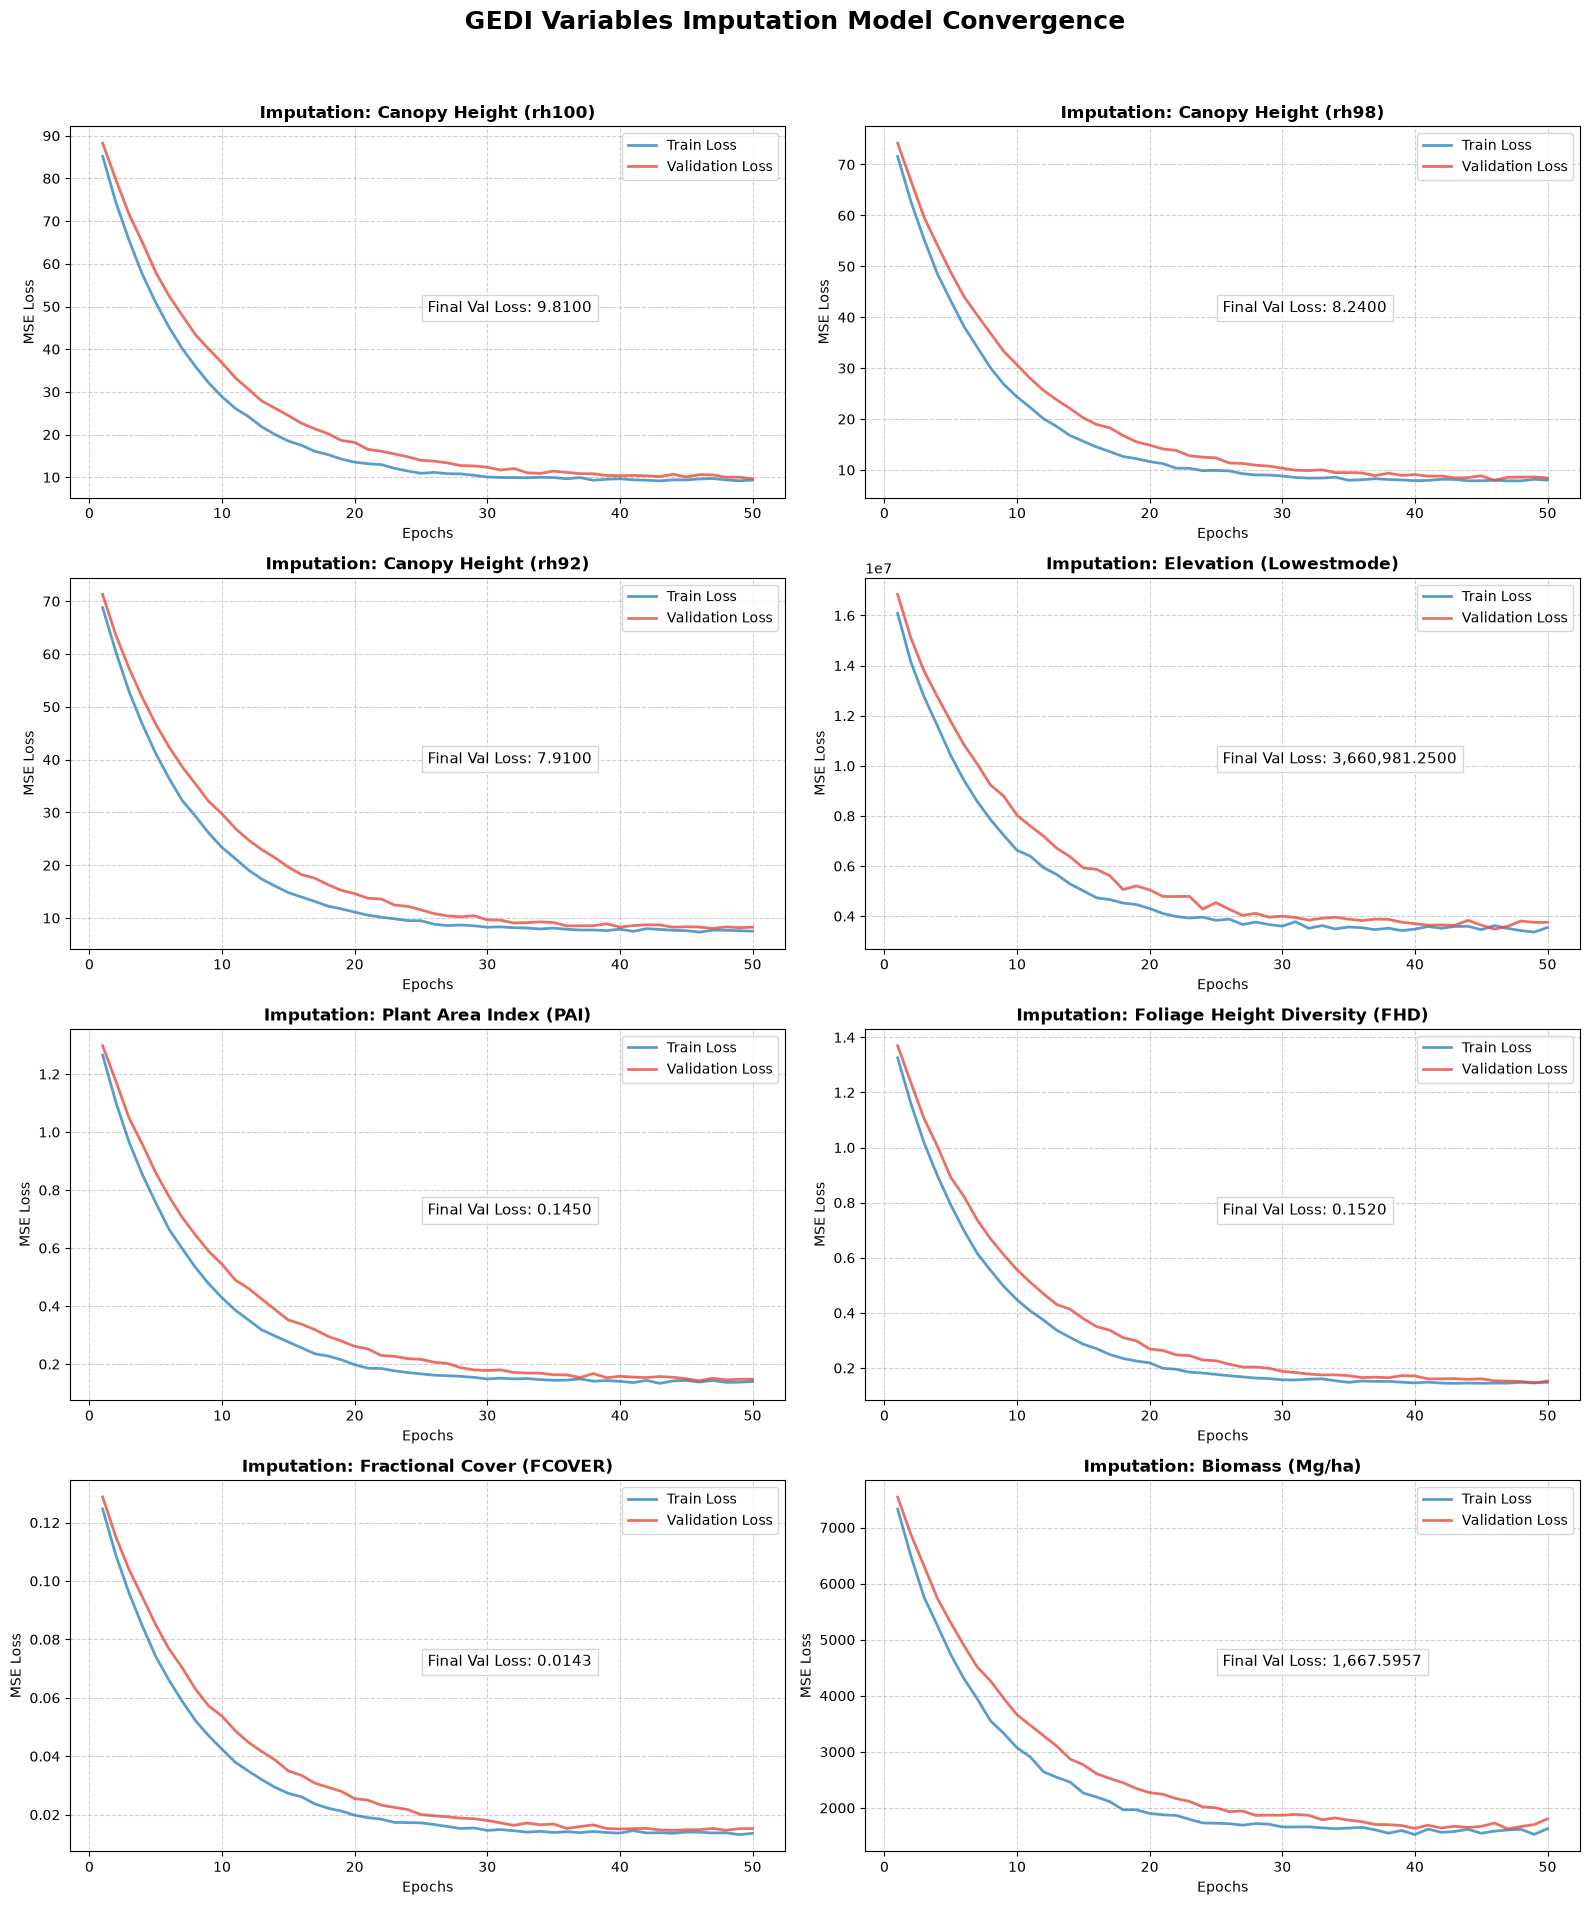

In [ ]:
import matplotlib.pyplot as plt

history_rh100 = model_rh100.fit(
    X_train_biomass,
    y_train_biomass,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)
history_rh100 = model_rh98.fit(
    X_train_biomass,
    y_train_biomass,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)
history_rh100 = model_rh92.fit(
    X_train_biomass,
    y_train_biomass,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)
history_rh100 = model_elevation.fit(
    X_train_biomass,
    y_train_biomass,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)
history_rh100 = model_rhpai.fit(
    X_train_biomass,
    y_train_biomass,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)
history_rh100 = model_fhd.fit(
    X_train_biomass,
    y_train_biomass,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)
history_rh100 = model_fcover.fit(
    X_train_biomass,
    y_train_biomass,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)
history_rh100 = model_biomass.fit(
    X_train_biomass,
    y_train_biomass,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)
histories = {
    'Canopy Height (rh100)': history_rh100, 
    'Canopy Height (rh98)': history_rh98,
    'Canopy Height (rh92)': history_rh92,
    'Elevation (Lowestmode)': history_elevation,
    'Plant Area Index (PAI)': history_pai,
    'Foliage Height Diversity (FHD)': history_fhd,
    'Fractional Cover (FCOVER)': history_fcover,
    'Biomass (Mg/ha)': history_biomass
}

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, (title, hist) in enumerate(histories.items()):
    axes[i].plot(hist.history['loss'], label='Train Loss', color='#2E86C1', linewidth=2)
    axes[i].plot(hist.history['val_loss'], label='Validation Loss', color='#E74C3C', linewidth=2)
    
    axes[i].set_title(f"Imputation: {title}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Epochs')
    axes[i].set_ylabel('MSE Loss')
    axes[i].grid(True, linestyle='--', alpha=0.6)
    axes[i].legend()

plt.suptitle('GEDI Variables Imputation Model Convergence', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()


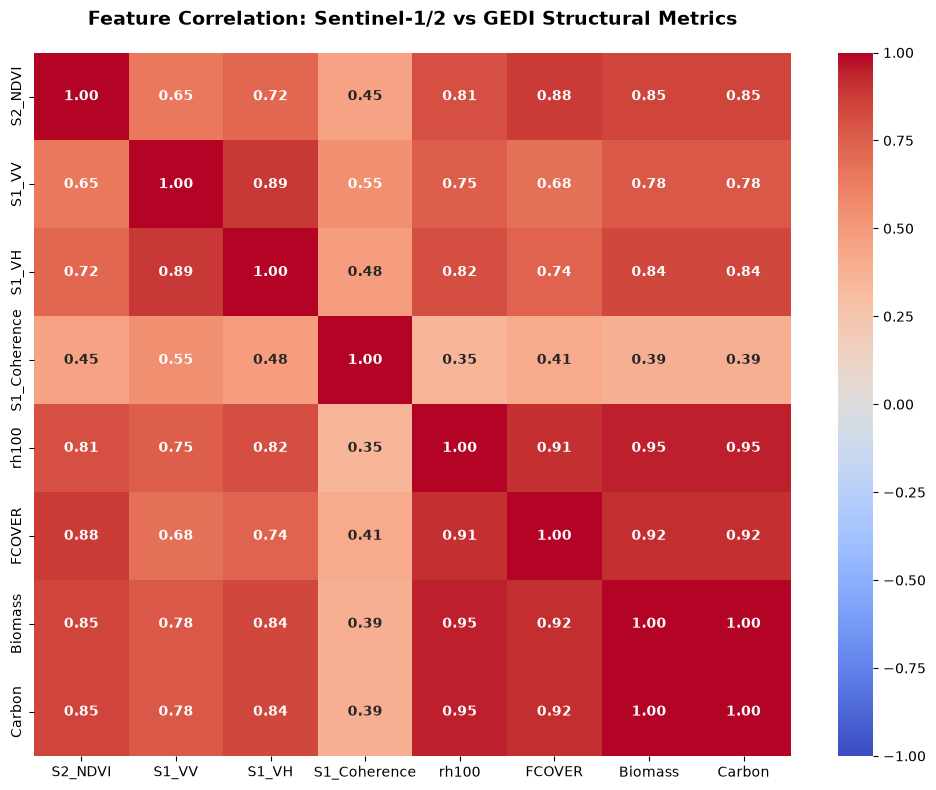

In [3]:
features_to_correlate = [
    'NDVI', 'VV_backscatter', 'VH_backscatter', 'VV_coherence', 
    'GEDI_canopy_height_rh100', 'GEDI_FCOVER', 'GEDI_biomass_Mg_ha', 'carbon_stock_MgC_ha'
]
# Calculate the TRUE correlation matrix from your dataset
true_corr_matrix = df3[features_to_correlate].corr()
# Clean up the labels for the plot
clean_labels = ['S2_NDVI', 'S1_VV', 'S1_VH', 'S1_Coherence', 'rh100', 'FCOVER', 'Biomass', 'Carbon']
plt.figure(figsize=(10, 8))
sns.heatmap(true_corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
            xticklabels=clean_labels, yticklabels=clean_labels, fmt='.2f', 
            annot_kws={'size': 10, 'weight': 'bold'})
plt.title('Feature Correlation: Sentinel-1/2 vs GEDI Structural Metrics', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# MONTHLY Carbon Absorbsion Caluculation

In [ ]:
CARBON_FRACTION = 0.47
CO2_TO_C_RATIO = 44.0 / 12.0
ANNUAL_BASE_SEQ_RATE = 6.0

df['carbon_stock_MgC_ha'] = df['GEDI_biomass_Mg_ha'] * CARBON_FRACTION
df['carbon_stock_tCO2e_ha'] = df['carbon_stock_MgC_ha'] * CO2_TO_C_RATIO
df['structure_weight'] = df['GEDI_PAI'] / df['GEDI_PAI'].mean()
df['monthly_absorption_MgC_ha'] = (ANNUAL_BASE_SEQ_RATE * df['structure_weight']) / 12.0
df['monthly_absorption_tCO2e_ha'] = df['monthly_absorption_MgC_ha'] * CO2_TO_C_RATIO
df.drop(columns=['structure_weight'], inplace=True)

print("Success: Added 'monthly_absorption_tCO2e_ha' to the dataframe.")
print(df[['latitude', 'longitude', 'date', 'monthly_absorption_tCO2e_ha']].head())

Success: Added 'monthly_absorption_tCO2e_ha' to the dataframe.
    latitude  longitude        date  monthly_absorption_tCO2e_ha
0  22.791063  54.246296  2021-01-01                     2.974641
1  22.791063  54.246296  2021-02-01                     0.382720
2  22.791063  54.246296  2021-03-01                     1.796868
3  22.791063  54.246296  2021-04-01                     0.179044
4  22.791063  54.246296  2021-05-01                     0.256280


In [ ]:
df.columns

Index(['latitude', 'longitude', 'VV_backscatter', 'VH_backscatter',
       'VV_coherence', 'VH_coherence', 'date', 'B1', 'B2', 'B3', 'B4', 'B5',
       'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'SCL', 'NDVI', 'NDWI',
       'NDSI', 'Moisture_index', 'SWIR', 'Scene_classification_map',
       'False_color', 'False_color_urban', 'Highlight_Optimized_Natural_Color',
       'True_color', 'GEDI_canopy_height_rh100', 'GEDI_canopy_height_rh98',
       'GEDI_canopy_height_rh92', 'GEDI_elevation_lowestmode', 'GEDI_PAI',
       'GEDI_FHD', 'GEDI_FCOVER', 'GEDI_biomass_Mg_ha', 'carbon_stock_MgC_ha',
       'carbon_stock_tCO2e_ha', 'monthly_absorption_MgC_ha',
       'monthly_absorption_tCO2e_ha'],
      dtype='object')

In [ ]:
df.to_csv('/content/drive/MyDrive/STAGE 1/S1_S2_GEDI_New_UAE_Imputed_Monthly.csv')

# PATCH Creation

In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv('/content/drive/MyDrive/STAGE 1/S1_S2_GEDI_New_UAE_Imputed_Monthly.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
unique_coords_df = df[['latitude', 'longitude']].drop_duplicates().copy()
unique_coords_df['patch_id'] = -1

print("Unique latitude and longitude pairs extracted and 'patch_id' initialized.")
print(unique_coords_df.head())

Unique latitude and longitude pairs extracted and 'patch_id' initialized.
      latitude  longitude  patch_id
0    22.791063  54.246296        -1
61   23.277425  53.784009        -1
122  23.951874  52.091746        -1
183  23.955674  52.077103        -1
244  23.957573  52.075011        -1


In [ ]:
from sklearn.cluster import DBSCAN

# Convert latitude and longitude to radians for haversine metric
unique_coords_radians = np.radians(unique_coords_df[['latitude', 'longitude']])

# Earth's radius in meters
R = 6371000
# Desired radius for clustering in meters
eps_meters = 500
# Convert eps (radius) from meters to radians for DBSCAN's haversine metric
eps_radians_for_unique_coords = eps_meters / R

# Apply DBSCAN clustering
dbsc_unique = DBSCAN(eps=eps_radians_for_unique_coords, min_samples=5, metric='haversine')
clusters_unique = dbsc_unique.fit_predict(unique_coords_radians)

# Assign the cluster labels as patch_id
unique_coords_df['patch_id'] = clusters_unique

print("DBSCAN clustering applied to unique coordinates and patch_id assigned.")
print(f"Number of unique clusters found (including noise -1): {len(np.unique(clusters_unique))}")
print(f"Number of noise points (assigned -1): {np.sum(clusters_unique == -1)}")
print("First 5 rows of unique_coords_df with new patch_id:")
print(unique_coords_df.head())

DBSCAN clustering applied to unique coordinates and patch_id assigned.
Number of unique clusters found (including noise -1): 75
Number of noise points (assigned -1): 683
First 5 rows of unique_coords_df with new patch_id:
      latitude  longitude  patch_id
0    22.791063  54.246296        -1
61   23.277425  53.784009        -1
122  23.951874  52.091746        -1
183  23.955674  52.077103        -1
244  23.957573  52.075011        -1


In [ ]:
df = df.merge(unique_coords_df[['latitude', 'longitude', 'patch_id']], on=['latitude', 'longitude'], how='left')

print("Patch IDs merged into the main DataFrame.")
print(df.head())

Patch IDs merged into the main DataFrame.
    latitude  longitude  VV_backscatter  VH_backscatter  VV_coherence  \
0  22.791063  54.246296      -24.314251      -31.478721      0.003703   
1  22.791063  54.246296      -25.507535      -30.963398      0.002819   
2  22.791063  54.246296      -25.626493      -31.186509      0.002737   
3  22.791063  54.246296      -23.189345      -31.998171      0.004816   
4  22.791063  54.246296      -22.832819      -25.969246      0.005209   

   VH_coherence        date     B1      B2      B3  ...  \
0      0.000711  2021-01-01  755.0  1004.5  1856.5  ...   
1      0.000801  2021-02-01  743.0  1055.0  1854.0  ...   
2      0.000761  2021-03-01  693.5  1009.0  1882.0  ...   
3      0.000642  2021-04-01  733.0  1026.0  1736.0  ...   
4      0.002530  2021-05-01  756.5  1032.0  1804.0  ...   

   GEDI_elevation_lowestmode  GEDI_PAI  GEDI_FHD  GEDI_FCOVER  \
0                -836.427979  0.275530  3.111608     0.128696   
1                -868.141479  0.03

In [ ]:
patch_absorption_summary = df[df['patch_id'] != -1].groupby('patch_id')['monthly_absorption_tCO2e_ha'].sum().reset_index()

print("Total monthly carbon absorption calculated for each DBSCAN patch.")
print(f"Number of DBSCAN patches with absorption data (excluding noise): {len(patch_absorption_summary)}")
print(patch_absorption_summary.head())

Total monthly carbon absorption calculated for each DBSCAN patch.
Number of DBSCAN patches with absorption data (excluding noise): 74
   patch_id  monthly_absorption_tCO2e_ha
0         0                  1199.485735
1         1                  1339.718000
2         2                   253.738441
3         3                  1093.134379
4         4                  3232.476798


In [ ]:
from scipy.spatial import ConvexHull
import numpy as np

# Group by patch_id (excluding noise points) and collect all unique coordinates for each patch
# Use df_filtered for patches with patch_id != -1
df_filtered_patches = df[df['patch_id'] != -1].copy()
patched_coords_dbscan = df_filtered_patches.groupby('patch_id')[['latitude', 'longitude']].apply(lambda x: x.drop_duplicates().values.tolist()).reset_index(name='coordinates')

# Create a list to store patch summary with polygons
patch_polygons_dbscan = []

for index, row in patched_coords_dbscan.iterrows():
    patch_id = row['patch_id']
    coords = np.array(row['coordinates'])

    if len(coords) >= 3: # A polygon requires at least 3 unique points
        try:
            hull = ConvexHull(coords)
            # Extract polygon coordinates in (lat, lon) format for Folium
            polygon_coords = coords[hull.vertices].tolist()
            # Close the polygon by appending the first point to the end
            polygon_coords.append(polygon_coords[0])
        except Exception as e:
            print(f"Could not compute ConvexHull for patch {patch_id}: {e}")
            polygon_coords = [] # Store an empty list if hull cannot be formed
    else:
        polygon_coords = [] # Not enough points to form a polygon

    patch_polygons_dbscan.append({
        'patch_id': patch_id,
        'polygon_coords': polygon_coords
    })

# Convert the list of dictionaries to a DataFrame
patch_polygons_dbscan_df = pd.DataFrame(patch_polygons_dbscan)

# Merge with the absorption summary to get the final clustered patches with polygons
clustered_patches_with_polygons_dbscan_df = pd.merge(patch_absorption_summary, patch_polygons_dbscan_df, on='patch_id', how='left')

print("Generated convex hull polygons for each DBSCAN patch.")
print(f"Number of DBSCAN patches with polygon data: {len(clustered_patches_with_polygons_dbscan_df)}")
print(clustered_patches_with_polygons_dbscan_df.head())

Could not compute ConvexHull for patch 67: QH6013 qhull input error: input is less than 2-dimensional since all points have the same x coordinate 25.59

While executing:  | qhull i Qt
Options selected for Qhull 2020.2.r 2020/08/31:
  run-id 1967759665  incidence  Qtriangulate  _pre-merge  _zero-centrum
  _max-width 0.0084  Error-roundoff 4.8e-14  _one-merge 2.4e-13
  _near-inside 1.2e-12  Visible-distance 9.5e-14  U-max-coplanar 9.5e-14
  Width-outside 1.9e-13  _wide-facet 5.7e-13  _maxoutside 2.9e-13

Generated convex hull polygons for each DBSCAN patch.
Number of DBSCAN patches with polygon data: 74
   patch_id  monthly_absorption_tCO2e_ha  \
0         0                  1199.485735   
1         1                  1339.718000   
2         2                   253.738441   
3         3                  1093.134379   
4         4                  3232.476798   

                                      polygon_coords  
0  [[23.95947323405253, 52.0624604136], [23.95947...  
1  [[23.98227148

In [ ]:
output_csv_path_dbscan = '/content/drive/MyDrive/STAGE 1/clustered_patches_with_polygons_dbscan.csv'
clustered_patches_with_polygons_dbscan_df.to_csv(output_csv_path_dbscan, index=False)

print(f"DBSCAN clustered patches with polygons saved to {output_csv_path_dbscan}")

DBSCAN clustered patches with polygons saved to /content/drive/MyDrive/STAGE 1/clustered_patches_with_polygons_dbscan.csv


In [ ]:
import folium

# Filter out patches that could not form a polygon (empty list in 'polygon_coords')
valid_polygons_dbscan_df = clustered_patches_with_polygons_dbscan_df[clustered_patches_with_polygons_dbscan_df['polygon_coords'].apply(lambda x: len(x) > 0)]

# Create a Folium map centered around the mean latitude and longitude of the clustered data
if not valid_polygons_dbscan_df.empty:
    # Calculate map center from the average of the polygon centroids
    map_center_lat_dbscan = valid_polygons_dbscan_df['polygon_coords'].apply(lambda x: np.mean([p[0] for p in x])).mean()
    map_center_lon_dbscan = valid_polygons_dbscan_df['polygon_coords'].apply(lambda x: np.mean([p[1] for p in x])).mean()
else:
    # Fallback if no valid polygons are found (e.g., all points were noise or <3 points)
    map_center_lat_dbscan = df['latitude'].mean()
    map_center_lon_dbscan = df['longitude'].mean()

m_dbscan = folium.Map(location=[map_center_lat_dbscan, map_center_lon_dbscan], zoom_start=9)

# Add polygons to the map
for index, row in valid_polygons_dbscan_df.iterrows():
    patch_id = row['patch_id']
    polygon_coords = row['polygon_coords']
    total_absorption = row['monthly_absorption_tCO2e_ha']

    # Create a tooltip with relevant information
    tooltip_content = f"Patch ID: {patch_id}<br>Total Monthly Absorption: {total_absorption:.2f} tCO2e/ha"

    # Add the polygon to the map
    folium.Polygon(
        locations=polygon_coords,
        color='green', # Using a different color to distinguish from previous map
        fill=True,
        fill_color='green',
        fill_opacity=0.3,
        tooltip=tooltip_content
    ).add_to(m_dbscan)

print("Interactive Folium map created for DBSCAN clustered patches.")
m_dbscan

Interactive Folium map created for DBSCAN clustered patches.


# Construct Sedimental Connectivity Edges

In [ ]:
clustered_patches_df = pd.read_csv('/content/clustered_patches_with_polygons_dbscan.csv')
print("clustered_patches_with_polygons_dbscan.csv loaded successfully into clustered_patches_df.")
print(clustered_patches_df.head())

clustered_patches_with_polygons_dbscan.csv loaded successfully into clustered_patches_df.
   patch_id  monthly_absorption_tCO2e_ha  \
0         0                  1199.485735   
1         1                  1339.718000   
2         2                   253.738441   
3         3                  1093.134379   
4         4                  3232.476798   

                                      polygon_coords  
0  [[23.95947323405253, 52.0624604136], [23.95947...  
1  [[23.982271489212007, 51.9181264344], [23.9803...  
2  [[24.115261310975608, 52.832241636], [24.12286...  
3  [[24.12856029315197, 53.909516988], [24.130460...  
4  [[24.17605665806754, 54.1458900264], [24.16085...  


In [ ]:
import numpy as np

# The 'polygon_coords' column is already in list format after loading the CSV, no need for ast.literal_eval

# Calculate the centroid for each patch, handling empty polygon_coords
clustered_patches_df['centroid_latitude'] = clustered_patches_df['polygon_coords'].apply(lambda x: np.mean([coord[0] for coord in x]) if (isinstance(x, list) and len(x) > 0) else np.nan)
clustered_patches_df['centroid_longitude'] = clustered_patches_df['polygon_coords'].apply(lambda x: np.mean([coord[1] for coord in x]) if (isinstance(x, list) and len(x) > 0) else np.nan)

print("Patch centroids calculated and added to clustered_patches_df.")
print(clustered_patches_df.head())

Patch centroids calculated and added to clustered_patches_df.
   patch_id  monthly_absorption_tCO2e_ha  \
0         0                  1199.485735   
1         1                  1339.718000   
2         2                   253.738441   
3         3                  1093.134379   
4         4                  3232.476798   

                                      polygon_coords  centroid_latitude  \
0  [[23.95947323405253, 52.0624604136], [23.95947...          23.961753   
1  [[23.982271489212007, 51.9181264344], [23.9803...          23.984443   
2  [[24.115261310975608, 52.832241636], [24.12286...          24.118586   
3  [[24.12856029315197, 53.909516988], [24.130460...          24.128085   
4  [[24.17605665806754, 54.1458900264], [24.16085...          24.175514   

   centroid_longitude  
0           52.053675  
1           51.914540  
2           52.833288  
3           53.916577  
4           54.133339  


In [ ]:
import numpy as np

# Define connectivity thresholds in kilometers
sedimental_threshold_km = 2
tidal_threshold_km = 5

# Haversine distance function
def haversine(lat1, lon1, lat2, lon2):
    R = 6371 # Earth radius in kilometers

    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)

    dlon = lon2_rad - lon1_rad
    dlat = lat2_rad - lat1_rad

    a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    distance = R * c
    return distance

print(f"Sedimental connectivity threshold: {sedimental_threshold_km} km")
print(f"Tidal connectivity threshold: {tidal_threshold_km} km")
print("Haversine distance function defined.")

Sedimental connectivity threshold: 2 km
Tidal connectivity threshold: 5 km
Haversine distance function defined.


In [ ]:
from itertools import combinations

patch_distances = []

# Get all unique patch IDs and their centroids
patches_info = clustered_patches_df[['patch_id', 'centroid_latitude', 'centroid_longitude']].dropna().set_index('patch_id')

# Iterate through all unique pairs of patches
for (id1, lat1, lon1), (id2, lat2, lon2) in combinations(patches_info.itertuples(), 2):
    distance = haversine(lat1, lon1, lat2, lon2)
    patch_distances.append({
        'patch_id_1': id1,
        'patch_id_2': id2,
        'distance_km': distance
    })

pairwise_distances_df = pd.DataFrame(patch_distances)

print("Pairwise distances between patch centroids calculated.")
print(pairwise_distances_df.head())

Pairwise distances between patch centroids calculated.
   patch_id_1  patch_id_2  distance_km
0           0           1    14.359824
1           0           2    81.067378
2           0           3   190.071000
3           0           4   212.474421
4           0           5   216.162945


In [ ]:
graph_edges = []

# Identify sedimental connectivity
sedimental_edges = pairwise_distances_df[pairwise_distances_df['distance_km'] <= sedimental_threshold_km]
for _, row in sedimental_edges.iterrows():
    graph_edges.append({
        'source': row['patch_id_1'],
        'target': row['patch_id_2'],
        'edge_type': 'sedimental',
        'distance_km': row['distance_km']
    })

# Identify tidal connectivity (if not already sedimental)
tidal_edges = pairwise_distances_df[pairwise_distances_df['distance_km'] <= tidal_threshold_km]
for _, row in tidal_edges.iterrows():
    # Only add tidal edges if they are not already classified as sedimental
    # This assumes sedimental connectivity implies tidal connectivity, but if it's explicitly tidal and not sedimental, we add it
    # A more robust check might involve ensuring unique (source, target) pairs for each type if they can overlap
    is_sedimental = any(edge['source'] == row['patch_id_1'] and edge['target'] == row['patch_id_2'] and edge['edge_type'] == 'sedimental' for edge in graph_edges)
    if not is_sedimental:
        graph_edges.append({
            'source': row['patch_id_1'],
            'target': row['patch_id_2'],
            'edge_type': 'tidal',
            'distance_km': row['distance_km']
        })

graph_edges_df = pd.DataFrame(graph_edges)

print("Sedimental and tidal connectivity edges generated.")
print(graph_edges_df.head())


Sedimental and tidal connectivity edges generated.
   source  target   edge_type  distance_km
0    19.0    20.0  sedimental     1.468261
1    25.0    26.0  sedimental     1.445149
2    40.0    42.0  sedimental     1.899410
3    40.0    46.0  sedimental     1.868109
4    41.0    44.0  sedimental     1.831465


In [ ]:
nodes_info_df = clustered_patches_df[['patch_id', 'centroid_latitude', 'centroid_longitude']].rename(columns={
    'patch_id': 'node_id',
    'centroid_latitude': 'latitude',
    'centroid_longitude': 'longitude'
})

# Merge graph_edges_df with nodes_info_df to get source node centroids
final_graph_df = pd.merge(graph_edges_df, nodes_info_df, left_on='source', right_on='node_id', how='left')
final_graph_df.rename(columns={
    'latitude': 'source_latitude',
    'longitude': 'source_longitude'
}, inplace=True)
final_graph_df.drop(columns=['node_id'], inplace=True)

# Merge again to get target node centroids
final_graph_df = pd.merge(final_graph_df, nodes_info_df, left_on='target', right_on='node_id', how='left')
final_graph_df.rename(columns={
    'latitude': 'target_latitude',
    'longitude': 'target_longitude'
}, inplace=True)
final_graph_df.drop(columns=['node_id'], inplace=True)

# Save the final graph DataFrame to CSV
output_csv_path = '/content/graph_edges.csv'
final_graph_df.to_csv(output_csv_path, index=False)

print(f"Graph structure including node centroids and edge types saved to {output_csv_path}")
print(final_graph_df.head())

Graph structure including node centroids and edge types saved to /content/graph_edges.csv
   source  target   edge_type  distance_km  source_latitude  source_longitude  \
0    19.0    20.0  sedimental     1.468261        24.300814         54.439904   
1    25.0    26.0  sedimental     1.445149        24.330262         54.438044   
2    40.0    42.0  sedimental     1.899410        24.527530         54.563552   
3    40.0    46.0  sedimental     1.868109        24.527530         54.563552   
4    41.0    44.0  sedimental     1.831465        24.529430         54.506097   

   target_latitude  target_longitude  
0        24.303727         54.425772  
1        24.342864         54.434558  
2        24.533467         54.545946  
3        24.542729         54.571421  
4        24.545198         54.511327  


# Construct Tidal Connectivity Edges (Heuristic)


In [ ]:
# Calculate connectivity summary for each patch
# Group by source and target to count sedimental and tidal connections

# Get all unique patch_ids from the main df as a base for connectivity summary
all_patch_ids = pd.DataFrame({'patch_id': df['patch_id'].unique()})

# Count outgoing sedimental connections
outgoing_sedimental = final_graph_df_loaded[final_graph_df_loaded['edge_type'] == 'sedimental'].groupby('source').size().reset_index(name='num_sedimental_outgoing')
outgoing_sedimental.rename(columns={'source': 'patch_id'}, inplace=True)

# Count incoming sedimental connections
incoming_sedimental = final_graph_df_loaded[final_graph_df_loaded['edge_type'] == 'sedimental'].groupby('target').size().reset_index(name='num_sedimental_incoming')
incoming_sedimental.rename(columns={'target': 'patch_id'}, inplace=True)

# Count outgoing tidal connections
outgoing_tidal = final_graph_df_loaded[final_graph_df_loaded['edge_type'] == 'tidal'].groupby('source').size().reset_index(name='num_tidal_outgoing')
outgoing_tidal.rename(columns={'source': 'patch_id'}, inplace=True)

# Count incoming tidal connections
incoming_tidal = final_graph_df_loaded[final_graph_df_loaded['edge_type'] == 'tidal'].groupby('target').size().reset_index(name='num_tidal_incoming')
incoming_tidal.rename(columns={'target': 'patch_id'}, inplace=True)

# Merge all connectivity counts into the all_patch_ids DataFrame
patch_connectivity_summary = all_patch_ids
patch_connectivity_summary = patch_connectivity_summary.merge(outgoing_sedimental, on='patch_id', how='left').fillna(0)
patch_connectivity_summary = patch_connectivity_summary.merge(incoming_sedimental, on='patch_id', how='left').fillna(0)
patch_connectivity_summary = patch_connectivity_summary.merge(outgoing_tidal, on='patch_id', how='left').fillna(0)
patch_connectivity_summary = patch_connectivity_summary.merge(incoming_tidal, on='patch_id', how='left').fillna(0)

# Calculate total connections for each type
patch_connectivity_summary['total_sedimental_connections'] = patch_connectivity_summary['num_sedimental_outgoing'] + patch_connectivity_summary['num_sedimental_incoming']
patch_connectivity_summary['total_tidal_connections'] = patch_connectivity_summary['num_tidal_outgoing'] + patch_connectivity_summary['num_tidal_incoming']

# Merge the connectivity summary into the main DataFrame (df)
df_with_connectivity = pd.merge(df, patch_connectivity_summary, on='patch_id', how='left')

print("Main DataFrame augmented with patch connectivity features:")
print(df_with_connectivity.head())

Main DataFrame augmented with patch connectivity features:
    latitude  longitude  VV_backscatter  VH_backscatter  VV_coherence  \
0  22.791063  54.246296      -24.314251      -31.478721      0.003703   
1  22.791063  54.246296      -25.507535      -30.963398      0.002819   
2  22.791063  54.246296      -25.626493      -31.186509      0.002737   
3  22.791063  54.246296      -23.189345      -31.998171      0.004816   
4  22.791063  54.246296      -22.832819      -25.969246      0.005209   

   VH_coherence        date     B1      B2      B3  ...  \
0      0.000711  2021-01-01  755.0  1004.5  1856.5  ...   
1      0.000801  2021-02-01  743.0  1055.0  1854.0  ...   
2      0.000761  2021-03-01  693.5  1009.0  1882.0  ...   
3      0.000642  2021-04-01  733.0  1026.0  1736.0  ...   
4      0.002530  2021-05-01  756.5  1032.0  1804.0  ...   

   carbon_stock_tCO2e_ha  monthly_absorption_MgC_ha  \
0               3.253420                   0.811266   
1               2.019052             

In [ ]:
import pandas as pd

final_graph_csv_path = '/content/graph_edges.csv'
final_graph_df_loaded = pd.read_csv(final_graph_csv_path)

print(f"Contents of {final_graph_csv_path}:")
print(final_graph_df_loaded.head())

Contents of /content/graph_edges.csv:
   source  target   edge_type  distance_km  source_latitude  source_longitude  \
0    19.0    20.0  sedimental     1.468261        24.300814         54.439904   
1    25.0    26.0  sedimental     1.445149        24.330262         54.438044   
2    40.0    42.0  sedimental     1.899410        24.527530         54.563552   
3    40.0    46.0  sedimental     1.868109        24.527530         54.563552   
4    41.0    44.0  sedimental     1.831465        24.529430         54.506097   

   target_latitude  target_longitude  
0        24.303727         54.425772  
1        24.342864         54.434558  
2        24.533467         54.545946  
3        24.542729         54.571421  
4        24.545198         54.511327  


In [ ]:
graph_edges = []

# Create a set to store unique sedimental edge pairs (undirected) to avoid duplication
sedimental_pairs_set = set()

# Iterate through pairwise_distances_df to identify and add sedimental edges
for _, row in pairwise_distances_df.iterrows():
    id1 = row['patch_id_1']
    id2 = row['patch_id_2']
    distance = row['distance_km']

    if distance <= sedimental_threshold_km:
        # Add bidirectional sedimental edges
        graph_edges.append({
            'source': id1,
            'target': id2,
            'edge_type': 'sedimental',
            'distance_km': distance
        })
        graph_edges.append({
            'source': id2,
            'target': id1,
            'edge_type': 'sedimental',
            'distance_km': distance
        })
        # Store the undirected pair in the set
        sedimental_pairs_set.add(tuple(sorted((id1, id2))))

# Get all unique patch IDs and their centroids for directional checks
patches_centroids = clustered_patches_df[['patch_id', 'centroid_latitude', 'centroid_longitude']].dropna().set_index('patch_id')

# Iterate through pairwise_distances_df again to identify and add tidal edges with directional heuristic
for _, row in pairwise_distances_df.iterrows():
    id1 = row['patch_id_1']
    id2 = row['patch_id_2']
    distance = row['distance_km']

    # Check if this pair is already covered by a sedimental edge (undirected)
    if tuple(sorted((id1, id2))) in sedimental_pairs_set:
        continue

    if distance <= tidal_threshold_km:
        # Retrieve centroids for directional heuristic
        lat1, lon1 = patches_centroids.loc[id1, ['centroid_latitude', 'centroid_longitude']]
        lat2, lon2 = patches_centroids.loc[id2, ['centroid_latitude', 'centroid_longitude']]

        # Apply Northwest to Southeast heuristic
        # Patch A is Northwest of Patch B if A.lat > B.lat (North) AND A.lon < B.lon (West)
        if lat1 > lat2 and lon1 < lon2:
            graph_edges.append({
                'source': id1,
                'target': id2,
                'edge_type': 'tidal',
                'distance_km': distance
            })
        elif lat2 > lat1 and lon2 < lon1:
            graph_edges.append({
                'source': id2,
                'target': id1,
                'edge_type': 'tidal',
                'distance_km': distance
            })

graph_edges_df = pd.DataFrame(graph_edges)

print("Refined sedimental and tidal connectivity edges generated with directional heuristic.")
print(graph_edges_df.head())

Refined sedimental and tidal connectivity edges generated with directional heuristic.
   source  target   edge_type  distance_km
0    19.0    20.0  sedimental     1.468261
1    20.0    19.0  sedimental     1.468261
2    25.0    26.0  sedimental     1.445149
3    26.0    25.0  sedimental     1.445149
4    40.0    42.0  sedimental     1.899410


# Data Preparing For ST-GNN

In [ ]:
node_feature_columns = [
    'patch_id', 'date',
    'VV_backscatter', 'VH_backscatter', 'VV_coherence', 'VH_coherence',
    'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12',
    'SCL', 'NDVI', 'NDWI', 'NDSI', 'Moisture_index', 'SWIR',
    'Scene_classification_map', 'False_color', 'False_color_urban',
    'Highlight_Optimized_Natural_Color', 'True_color',
    'GEDI_canopy_height_rh100', 'GEDI_canopy_height_rh98',
    'GEDI_canopy_height_rh92', 'GEDI_elevation_lowestmode', 'GEDI_PAI',
    'GEDI_FHD', 'GEDI_FCOVER', 'GEDI_biomass_Mg_ha',
    'carbon_stock_MgC_ha', 'carbon_stock_tCO2e_ha',
    'monthly_absorption_MgC_ha', 'monthly_absorption_tCO2e_ha',
    'num_sedimental_outgoing', 'num_sedimental_incoming',
    'num_tidal_outgoing', 'num_tidal_incoming',
    'total_sedimental_connections', 'total_tidal_connections'
]

# Create node_features_df by selecting these columns
node_features_df = df_with_connectivity[node_feature_columns].copy()

# Filter out rows where patch_id is -1 (noise points)
node_features_df = node_features_df[node_features_df['patch_id'] != -1]

# Convert 'date' column to datetime objects
node_features_df['date'] = pd.to_datetime(node_features_df['date'])

print("node_features_df created, filtered for noise points, and 'date' column converted to datetime.")
print(node_features_df.head())
print(node_features_df.info())

node_features_df created, filtered for noise points, and 'date' column converted to datetime.
     patch_id       date  VV_backscatter  VH_backscatter  VV_coherence  \
305         0 2021-01-01      -15.554785      -25.245469      0.027831   
306         0 2021-02-01      -18.326845      -29.934581      0.014700   
307         0 2021-03-01      -16.230624      -25.245771      0.023820   
308         0 2021-04-01      -20.372806      -31.285018      0.009177   
309         0 2021-05-01      -19.173596      -24.600743      0.012096   

     VH_coherence      B1      B2      B3      B4  ...  carbon_stock_MgC_ha  \
305      0.002988  1555.0  1778.0  2144.0  2490.0  ...             0.550650   
306      0.001015  1556.0  1620.0  2053.0  2420.0  ...             0.550650   
307      0.002988  1745.0  1886.0  2338.0  2706.0  ...             0.432335   
308      0.000744  1879.5  2054.0  2485.0  2834.0  ...             0.705339   
309      0.003467  1907.5  2084.0  2463.0  2840.0  ...            

In [ ]:
from sklearn.preprocessing import StandardScaler

print("Missing values in node_features_df before scaling:")
print(node_features_df.isnull().sum().sum())

# Identify numerical columns to scale (excluding 'patch_id' and 'date')
numerical_cols_to_scale = node_features_df.select_dtypes(include=np.number).columns.tolist()
numerical_cols_to_scale = [col for col in numerical_cols_to_scale if col not in ['patch_id']]

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the identified numerical columns
node_features_df[numerical_cols_to_scale] = scaler.fit_transform(node_features_df[numerical_cols_to_scale])

print("\nNumerical features in node_features_df scaled successfully.")
print(node_features_df.head())
print(node_features_df.info())

Missing values in node_features_df before scaling:
0

Numerical features in node_features_df scaled successfully.
     patch_id       date  VV_backscatter  VH_backscatter  VV_coherence  \
305         0 2021-01-01       -1.005493       -1.260798     -0.881456   
306         0 2021-02-01       -1.639779       -2.183316     -1.023260   
307         0 2021-03-01       -1.160135       -1.260857     -0.924770   
308         0 2021-04-01       -2.107922       -2.448995     -1.082901   
309         0 2021-05-01       -1.833527       -1.133957     -1.051382   

     VH_coherence        B1        B2        B3        B4  ...  \
305     -0.447192  1.312141  1.096838  0.826471  1.454899  ...   
306     -0.492933  1.313999  0.860925  0.711260  1.367479  ...   
307     -0.447196  1.665118  1.258095  1.072086  1.724650  ...   
308     -0.499222  1.914988  1.508939  1.258196  1.884503  ...   
309     -0.436105  1.967005  1.553733  1.230343  1.891996  ...   

     carbon_stock_MgC_ha  carbon_stock_tCO2e

In [ ]:
unique_patch_ids = node_features_df['patch_id'].unique()
patch_id_to_index = {patch_id: index for index, patch_id in enumerate(unique_patch_ids)}

print("Mapping created for patch_id to numerical index.")
print(list(patch_id_to_index.items())[:5])

Mapping created for patch_id to numerical index.
[(np.int64(0), 0), (np.int64(1), 1), (np.int64(2), 2), (np.int64(3), 3), (np.int64(4), 4)]


In [ ]:
num_patches = len(unique_patch_ids)
adjacency_matrix = np.zeros((num_patches, num_patches))

# Define weights for edge types
sedimental_weight = 1.0
tidal_weight = 0.5 # A lower weight for tidal to represent weaker or different connectivity

# Populate the adjacency matrix
for index, row in final_graph_df_loaded.iterrows():
    source_patch_id = row['source']
    target_patch_id = row['target']
    edge_type = row['edge_type']

    # Only process patches that exist in our mapping (i.e., not noise points with patch_id = -1)
    if source_patch_id in patch_id_to_index and target_patch_id in patch_id_to_index:
        source_index = patch_id_to_index[source_patch_id]
        target_index = patch_id_to_index[target_patch_id]

        if edge_type == 'sedimental':
            # Sedimental connections are bidirectional and have a fixed weight
            adjacency_matrix[source_index, target_index] = sedimental_weight
            adjacency_matrix[target_index, source_index] = sedimental_weight
        elif edge_type == 'tidal':
            # Tidal connections are directional and have a fixed weight, if not already sedimental
            # Check if there is already a sedimental connection (which has higher weight/priority)
            if adjacency_matrix[source_index, target_index] == 0:
                adjacency_matrix[source_index, target_index] = tidal_weight

print(f"Adjacency matrix created with shape: {adjacency_matrix.shape}")
print("First 5x5 block of the adjacency matrix:\n", adjacency_matrix[:5, :5])

Adjacency matrix created with shape: (74, 74)
First 5x5 block of the adjacency matrix:
 [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


In [ ]:
look_back = 3
forecast_horizon = 1

# Identify feature columns (excluding 'patch_id', 'date', and the target)
feature_columns = [col for col in node_features_df.columns if col not in ['patch_id', 'date', 'monthly_absorption_tCO2e_ha']]

# Determine the index of the target variable within these feature columns if it were included for Y extraction
# This is done by creating a temporary list of all numerical columns that will be used in the sequences for accurate indexing.
all_numerical_cols_for_sequence = [col for col in node_features_df.select_dtypes(include=np.number).columns if col not in ['patch_id', 'date']]
target_feature_index = all_numerical_cols_for_sequence.index('monthly_absorption_tCO2e_ha')

print(f"Look back period: {look_back}")
print(f"Forecast horizon: {forecast_horizon}")
print(f"Number of feature columns: {len(feature_columns)}")
print(f"First 5 feature columns: {feature_columns[:5]}")
print(f"Index of target variable (monthly_absorption_tCO2e_ha) in numerical features: {target_feature_index}")

Look back period: 3
Forecast horizon: 1
Number of feature columns: 44
First 5 feature columns: ['VV_backscatter', 'VH_backscatter', 'VV_coherence', 'VH_coherence', 'B1']
Index of target variable (monthly_absorption_tCO2e_ha) in numerical features: 38


In [ ]:
sequences = []

# Group by patch_id to process each patch independently
grouped_by_patch = node_features_df.groupby('patch_id')

for patch_id, group in grouped_by_patch:
    # Sort by date to ensure chronological order
    group = group.sort_values(by='date').reset_index(drop=True)

    # Extract only the numerical feature columns for sequence generation
    patch_data = group[feature_columns + ['monthly_absorption_tCO2e_ha']].values

    # Generate sequences
    for i in range(len(patch_data) - look_back - forecast_horizon + 1):
        # Input sequence X
        X = patch_data[i : i + look_back, :-1] # All feature columns except the last one (target)

        # Target Y (the monthly_absorption_tCO2e_ha for the forecast horizon)
        # The target feature is the last column in patch_data
        Y = patch_data[i + look_back + forecast_horizon - 1, -1] # Last column is 'monthly_absorption_tCO2e_ha'

        sequences.append((X, Y, patch_id))

print(f"Generated {len(sequences)} spatio-temporal sequences.")
print(f"Example sequence X shape: {sequences[0][0].shape}")
print(f"Example sequence Y value: {sequences[0][1]}")
print(f"Example sequence patch_id: {sequences[0][2]}")

Generated 200712 spatio-temporal sequences.
Example sequence X shape: (3, 44)
Example sequence Y value: -0.5224598937808974
Example sequence patch_id: 0


In [ ]:
total_time_steps = node_features_df['date'].nunique()

train_split = int(0.8 * total_time_steps)
val_split = int(0.9 * total_time_steps)

# Get unique sorted dates to determine split points chronologically
unique_dates = sorted(node_features_df['date'].unique())
train_dates = unique_dates[:train_split]
val_dates = unique_dates[train_split:val_split]
test_dates = unique_dates[val_split:]

X, Y, patch_ids = zip(*sequences)
X = np.array(X)
Y = np.array(Y)
patch_ids = np.array(patch_ids)

# Create a DataFrame to map sequences to their corresponding dates
sequence_dates_df = node_features_df[['patch_id', 'date']].drop_duplicates()

# Get the date for each sequence based on its patch_id and the date of the last time step in X
sequence_dates = []
for i, (seq_X, _, seq_patch_id) in enumerate(sequences):
    # For each sequence, find the date corresponding to the *last* time step of its input (X)
    # This is an approximation as exact date for each sequence element is not stored with X
    # A more precise way would be to reconstruct dates based on original dataframe's index/time_step
    # For simplicity, we assume the date of the (i + look_back - 1)-th entry in the original sorted group

    # Re-group by patch_id and sort by date for consistent indexing
    patch_group = node_features_df[node_features_df['patch_id'] == seq_patch_id].sort_values(by='date').reset_index(drop=True)

    # Find the starting index for this sequence within its patch_group based on existing sequence generation logic
    # The date associated with the *prediction* Y is (i + look_back + forecast_horizon - 1)
    # The date associated with the *last input* X is (i + look_back - 1)

    # This is a critical point: `sequences` were generated by looping `i` from `0` to `len(patch_data) - look_back - forecast_horizon + 1`.
    # The `i` here refers to the starting index of the `look_back` window.
    # The date for the `Y` (prediction) corresponds to `i + look_back + forecast_horizon - 1` in the original `patch_group`.

    # To assign a date to each sequence for splitting, we'll use the date of the target (Y)
    if (i + look_back + forecast_horizon - 1) < len(patch_group):
        sequence_dates.append(patch_group.loc[i + look_back + forecast_horizon - 1, 'date'])
    else:
        sequence_dates.append(pd.NaT) # Should not happen if sequence generation logic is sound


# Convert to a Series for easier comparison
sequence_dates = pd.Series(sequence_dates)

# Filter sequences based on dates
train_indices = sequence_dates.index[sequence_dates.isin(train_dates)].tolist()
val_indices = sequence_dates.index[sequence_dates.isin(val_dates)].tolist()
test_indices = sequence_dates.index[sequence_dates.isin(test_dates)].tolist()

X_train, Y_train, patch_ids_train = X[train_indices], Y[train_indices], patch_ids[train_indices]
X_val, Y_val, patch_ids_val = X[val_indices], Y[val_indices], patch_ids[val_indices]
X_test, Y_test, patch_ids_test = X[test_indices], Y[test_indices], patch_ids[test_indices]


print(f"Total sequences: {len(sequences)}")
print(f"Training sequences: {len(X_train)}")
print(f"Validation sequences: {len(X_val)}")
print(f"Test sequences: {len(X_test)}")

print(f"X_train shape: {X_train.shape}, Y_train shape: {Y_train.shape}")
print(f"X_val shape: {X_val.shape}, Y_val shape: {Y_val.shape}")
print(f"X_test shape: {X_test.shape}, Y_test shape: {Y_test.shape}")

Total sequences: 200712
Training sequences: 525
Validation sequences: 66
Test sequences: 147
X_train shape: (525, 3, 44), Y_train shape: (525,)
X_val shape: (66, 3, 44), Y_val shape: (66,)
X_test shape: (147, 3, 44), Y_test shape: (147,)


# ST-GNN Model Architecture




In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Dense, LSTM, Input, TimeDistributed, GRU, BatchNormalization, Dropout
from tensorflow.keras.models import Model

print("TensorFlow, Keras layers, and Model imported successfully.")

TensorFlow, Keras layers, and Model imported successfully.


In [ ]:
class GraphConvolutionLayer(Layer):
    def __init__(self, output_dim, activation=None, **kwargs):
        super(GraphConvolutionLayer, self).__init__(**kwargs)
        self.output_dim = output_dim
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        # input_shape[0] is (batch_size, time_steps, num_nodes, num_features)
        # self.add_weight creates trainable weights for the layer
        self.dense_layer = Dense(self.output_dim, use_bias=True)
        self.built = True

    def call(self, inputs, adjacency_matrix):
        # inputs shape: (batch_size, num_time_steps, num_nodes, num_features)
        # adjacency_matrix shape: (num_nodes, num_nodes) - this is static

        # Apply dense transformation to each node's features
        # self.dense_layer(inputs) will broadcast across time_steps
        transformed_features = self.dense_layer(inputs) # Shape: (batch_size, num_time_steps, num_nodes, output_dim)

        # Perform graph convolution: A * XW
        # Adjacency matrix (num_nodes, num_nodes) @ transformed_features (batch_size, num_time_steps, num_nodes, output_dim)
        # To do this, we need to permute dimensions of transformed_features
        # Permute to (batch_size, num_time_steps, output_dim, num_nodes) to match matrix multiplication
        # Reshape transformed_features to (batch_size * num_time_steps, num_nodes, output_dim)

        batch_size = tf.shape(transformed_features)[0]
        time_steps = tf.shape(transformed_features)[1]
        num_nodes = tf.shape(transformed_features)[2]

        # Reshape transformed_features for batched matrix multiplication
        reshaped_features = tf.reshape(transformed_features, (-1, num_nodes, self.output_dim))

        # Perform the graph convolution for each (batch, time_step) combination
        # Adjacency matrix is static, so it applies to all batch and time steps
        graph_convolved_features = tf.einsum('ij,bjk->bik', adjacency_matrix, reshaped_features)

        # Reshape back to original (batch_size, time_steps, num_nodes, output_dim)
        output = tf.reshape(graph_convolved_features, (batch_size, time_steps, num_nodes, self.output_dim))

        if self.activation is not None:
            output = self.activation(output)
        return output

    def get_config(self):
        config = super(GraphConvolutionLayer, self).get_config()
        config.update({
            'output_dim': self.output_dim,
            'activation': tf.keras.activations.serialize(self.activation)
        })
        return config

print("GraphConvolutionLayer custom Keras layer defined.")

GraphConvolutionLayer custom Keras layer defined.


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Dense, LSTM, Input, TimeDistributed, GRU, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Clear any previous TensorFlow graph and session to prevent variable creation conflicts
tf.keras.backend.clear_session()

num_patches = num_patches # Number of unique patches, obtained from previous step
num_features = X_train.shape[-1] # Number of features per node

# Define model inputs
input_features = Input(shape=(look_back, num_patches, num_features), name='input_features')
# input_adjacency is no longer a Keras Input layer for the Model, as it will be an attribute of the GCL layer.

# Redefine GraphConvolutionLayer to correctly handle arguments from TimeDistributed
class GraphConvolutionLayer(Layer):
    def __init__(self, output_dim, activation=None, adjacency_matrix=None, **kwargs):
        super(GraphConvolutionLayer, self).__init__(**kwargs)
        self.output_dim = output_dim
        self.activation = tf.keras.activations.get(activation)
        self.dense_layer = None # Initialize here, build later
        # Store the adjacency matrix as an attribute of the layer instance
        self.adjacency_matrix_np = adjacency_matrix # Store as numpy initially
        self.adj_constant = None # Will be tf.constant in build()

    def build(self, input_shape):
        # input_shape here will be the shape of node_features_at_t for one timestep: (None, num_nodes, num_features)
        self.dense_layer = Dense(self.output_dim, use_bias=True)
        # Convert the numpy adjacency matrix to a TensorFlow constant once during build
        if self.adjacency_matrix_np is not None:
            self.adj_constant = tf.constant(self.adjacency_matrix_np, dtype=tf.float32)
        else:
            raise ValueError("Adjacency matrix must be provided during initialization.")

        self.built = True

    def call(self, inputs, training=None): # Only inputs and training are passed by TimeDistributed
        # inputs shape: (batch_size, num_nodes, num_features) (for one time step)
        # self.adjacency_matrix shape: (num_nodes, num_nodes)

        # Apply dense transformation to each node's features
        transformed_features = self.dense_layer(inputs) # Shape: (batch_size, num_nodes, output_dim)

        # Perform graph convolution: A * XW using the internal adjacency_matrix
        graph_convolved_features = tf.einsum('ij,bjk->bik', self.adj_constant, transformed_features)

        output = graph_convolved_features

        if self.activation is not None:
            output = self.activation(output)
        return output

    def compute_output_shape(self, input_shape):
        # input_shape is (batch_size, num_nodes, num_features)
        # Output shape is (batch_size, num_nodes, output_dim)
        return (input_shape[0], input_shape[1], self.output_dim)

    def get_config(self):
        config = super(GraphConvolutionLayer, self).get_config()
        config.update(
            {
                'output_dim': self.output_dim,
                'activation': tf.keras.activations.serialize(self.activation)
                # adjacency_matrix is not included in config as it's a non-trainable, static input set at instantiation
            }
        )
        return config

# Instantiate GraphConvolutionLayer with the actual adjacency matrix (numpy array)
gcn_layer_instance = GraphConvolutionLayer(output_dim=64, activation='relu', adjacency_matrix=adjacency_matrix)

# Apply TimeDistributed GCN layer
# TimeDistributed now only operates on input_features, and the GCN layer internally uses its stored adjacency_matrix
gcn_output = TimeDistributed(gcn_layer_instance, name='gcn_layer')(input_features)

# Reshape GCN output for RNN layer using Keras Reshape layer
# Expected shape for RNN: (batch_size, timesteps, features)
# After GCN, shape is (batch_size, look_back, num_patches, units)
# We need to flatten num_patches * units into one feature dimension for the RNN
rnn_input = Reshape((look_back, num_patches * 64))(gcn_output)

# Apply RNN layer (GRU in this case)
rnn_output = GRU(units=128, activation='relu', name='gru_layer')(rnn_input)

# Output layer for regression
output = Dense(1, activation='linear', name='output_layer')(rnn_output)

# Define the ST-GNN model. Only input_features is an explicit input to the model.
st_gnn_model = Model(inputs=[input_features], outputs=output)

# Compile the model
st_gnn_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mse'])

print("ST-GNN model architecture defined.")
st_gnn_model.summary()

ST-GNN model architecture defined.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)     │ (None, 3, 74, 44)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gcn_layer (TimeDistributed)     │ (None, 3, 74, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 3, 4736)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_layer (GRU)                 │ (None, 128)            │     1,868,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,868,673 (7.13 MB)

 Trainable params: 1,868,673 (7.13 MB)

 Non-trainable params: 0 (0.00 B)

# Compile and Train ST-GNN Model



In [ ]:
import numpy as np

# Ensure node_features_df is sorted by date and patch_id
node_features_df_sorted = node_features_df.sort_values(by=['date', 'patch_id']).reset_index(drop=True)

# `unique_patch_ids`, `patch_id_to_index`, `num_patches`, `feature_columns`, `num_features` are from previous steps.
# `look_back` and `forecast_horizon` are also defined.

# Create a full 3D tensor of features and a 2D tensor of targets, indexed by (time_step, patch_index)
# `num_time_steps_overall` is the count of unique dates
unique_dates_list = sorted(node_features_df_sorted['date'].unique())
num_time_steps_overall = len(unique_dates_list)

# `feature_columns` already excludes 'monthly_absorption_tCO2e_ha'
# `num_features` is `len(feature_columns)`
full_features_tensor = np.zeros((num_time_steps_overall, num_patches, num_features))
full_targets_tensor = np.zeros((num_time_steps_overall, num_patches)) # Store individual targets for aggregation

# Populate these tensors
for t_idx, current_date in enumerate(unique_dates_list):
    df_at_current_date = node_features_df_sorted[node_features_df_sorted['date'] == current_date]
    for _, row in df_at_current_date.iterrows():
        patch_matrix_idx = patch_id_to_index[row['patch_id']]
        full_features_tensor[t_idx, patch_matrix_idx, :] = row[feature_columns].values
        full_targets_tensor[t_idx, patch_matrix_idx] = row['monthly_absorption_tCO2e_ha']

# Generate spatio-temporal sequences (X) and global target (Y)
X_st_sequences_list = []
Y_st_targets_list = []

for i in range(num_time_steps_overall - look_back - forecast_horizon + 1):
    # X_seq will be (look_back, num_patches, num_features)
    X_seq = full_features_tensor[i : i + look_back, :, :]
    X_st_sequences_list.append(X_seq)

    # Y_seq will be a scalar representing the aggregated target for the entire graph
    # at the forecast horizon time step.
    # The time index for the target is `i + look_back + forecast_horizon - 1`.
    target_time_step_idx = i + look_back + forecast_horizon - 1
    Y_aggregated_target = np.mean(full_targets_tensor[target_time_step_idx, :]) # Mean across all patches

    Y_st_targets_list.append(Y_aggregated_target)

X_final = np.array(X_st_sequences_list) # (num_samples, look_back, num_patches, num_features)
Y_final = np.array(Y_st_targets_list)   # (num_samples,)

print(f"Generated {len(X_final)} spatio-temporal sequences.")
print(f"Example sequence X shape: {X_final[0].shape}")
print(f"Example sequence Y value: {Y_final[0]}")

# --- Data Splitting (Corrected for new X_final and Y_final) ---

total_generated_sequences = len(X_final)
train_split_idx = int(0.8 * total_generated_sequences)
val_split_idx = int(0.9 * total_generated_sequences)

X_train = X_final[:train_split_idx]
Y_train = Y_final[:train_split_idx]

X_val = X_final[train_split_idx:val_split_idx]
Y_val = Y_final[train_split_idx:val_split_idx]

X_test = X_final[val_split_idx:]
Y_test = Y_final[val_split_idx:]

print(f"Total sequences: {total_generated_sequences}")
print(f"Training sequences: {len(X_train)}")
print(f"Validation sequences: {len(X_val)}")
print(f"Test sequences: {len(X_test)}")

print(f"X_train shape: {X_train.shape}, Y_train shape: {Y_train.shape}")
print(f"X_val shape: {X_val.shape}, Y_val shape: {Y_val.shape}")
print(f"X_test shape: {X_test.shape}, Y_test shape: {Y_test.shape}")

Generated 58 spatio-temporal sequences.
Example sequence X shape: (3, 74, 44)
Example sequence Y value: -0.22296112174829527
Total sequences: 58
Training sequences: 46
Validation sequences: 6
Test sequences: 6
X_train shape: (46, 3, 74, 44), Y_train shape: (46,)
X_val shape: (6, 3, 74, 44), Y_val shape: (6,)
X_test shape: (6, 3, 74, 44), Y_test shape: (6,)


In [ ]:
# Training part
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

history = st_gnn_model.fit(
    X_train,
    Y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, Y_val),
    callbacks=[early_stopping],
    verbose=1
)

print("ST-GNN model training completed.")

ST-GNN model architecture defined.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)     │ (None, 3, 74, 44)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gcn_layer (TimeDistributed)     │ (None, 3, 74, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 3, 4736)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_layer (GRU)                 │ (None, 128)            │     1,868,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,868,673 (7.13 MB)

 Trainable params: 1,868,673 (7.13 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 542ms/step - loss: 8.0942 - mse: 8.0942 - val_loss: 2.6255 - val_mse: 2.6255
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 3.2583 - mse: 3.2583 - val_loss: 5.2227 - val_mse: 5.2227
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 4.5587 - mse: 4.5587 - val_loss: 2.7515 - val_mse: 2.7515
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - loss: 1.9989 - mse: 1.9989 - val_loss: 0.9407 - val_mse: 0.9407
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.5278 - mse: 0.5278 - val_loss: 0.2287 - val_mse: 0.2287
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.0913 - mse: 0.0913 - val_loss: 0.1419 - val_mse: 0.1419
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.1933 - mse: 0.1933 - val_loss: 0.1593 - val_mse: 0.1593
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.2049 - mse: 0.2049 - val_loss: 0.1402 - val_mse: 0.1402
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 0.0955 - mse: 

# Evaluate ST-GNN Model Performance


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("Required metrics imported from sklearn.metrics.")

Required metrics imported from sklearn.metrics.


In [ ]:
y_pred = st_gnn_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(Y_test, y_pred))
mae = mean_absolute_error(Y_test, y_pred)

print(f"ST-GNN Model Evaluation on Test Data:")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step
ST-GNN Model Evaluation on Test Data:
Root Mean Squared Error (RMSE): 0.0874
Mean Absolute Error (MAE): 0.0740


# GRAPH Visual on HeatMap

In [ ]:
import tensorflow as tf

# Save the model in .h5 format
output_h5_path = '/content/drive/MyDrive/STAGE 1/STGNN_MODEL.h5'
st_gnn_model.save(output_h5_path)
print(f"Model saved successfully to {output_h5_path} (H5 format).")

# Note: Saving to .pt (PyTorch format) is not directly possible for a TensorFlow/Keras model.
# It would require converting the model to a PyTorch architecture first.

# Optional: Saving to .pkl format (generally not recommended for Keras models)
# import pickle
# output_pkl_path = '/content/STGNN_MODEL.pkl'
# with open(output_pkl_path, 'wb') as f:
#    pickle.dump(st_gnn_model, f)
# print(f"Model saved successfully to {output_pkl_path} (PKL format - with caution).")

Model saved successfully to /content/drive/MyDrive/STAGE 1/STGNN_MODEL.h5 (H5 format).


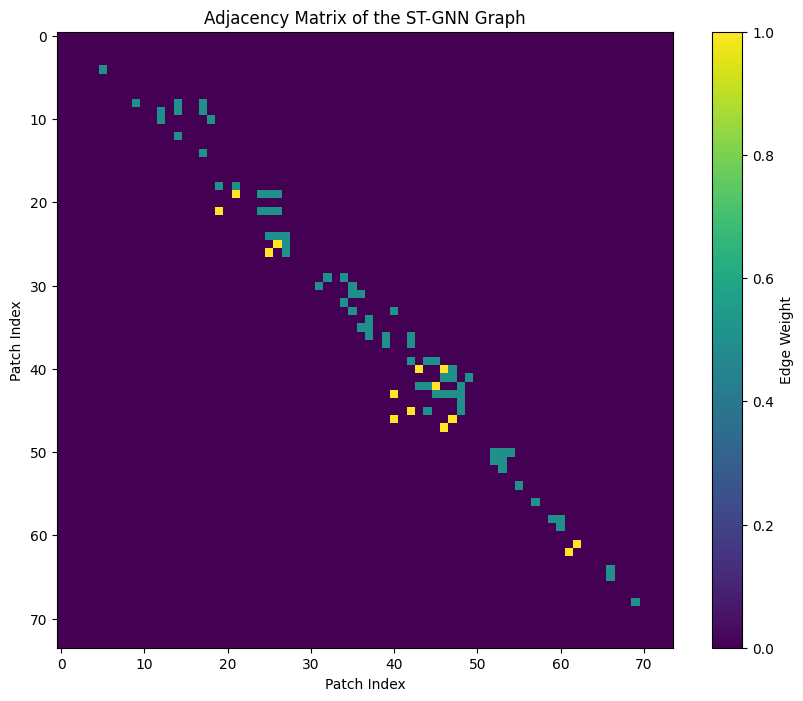

Adjacency matrix shape: (74, 74)
Number of unique patches (nodes): 74
Number of non-zero entries (edges): 86


In [ ]:
import matplotlib.pyplot as plt

# Assuming 'adjacency_matrix' is already defined from previous steps

plt.figure(figsize=(10, 8))
plt.imshow(adjacency_matrix, cmap='viridis', origin='upper')
plt.colorbar(label='Edge Weight')
plt.title('Adjacency Matrix of the ST-GNN Graph')
plt.xlabel('Patch Index')
plt.ylabel('Patch Index')
plt.show()

print(f"Adjacency matrix shape: {adjacency_matrix.shape}")
print(f"Number of unique patches (nodes): {num_patches}")
print(f"Number of non-zero entries (edges): {np.count_nonzero(adjacency_matrix)}")

# GRAPH Visual on Graph

In [ ]:
import pandas as pd

final_graph_csv_path = '/content/graph_edges.csv'
final_graph_df_loaded = pd.read_csv(final_graph_csv_path)

print(f"Contents of {final_graph_csv_path}:")
print(final_graph_df_loaded.head())

Contents of /content/graph_edges.csv:
   source  target   edge_type  distance_km  source_latitude  source_longitude  \
0    19.0    20.0  sedimental     1.468261        24.300814         54.439904   
1    25.0    26.0  sedimental     1.445149        24.330262         54.438044   
2    40.0    42.0  sedimental     1.899410        24.527530         54.563552   
3    40.0    46.0  sedimental     1.868109        24.527530         54.563552   
4    41.0    44.0  sedimental     1.831465        24.529430         54.506097   

   target_latitude  target_longitude  
0        24.303727         54.425772  
1        24.342864         54.434558  
2        24.533467         54.545946  
3        24.542729         54.571421  
4        24.545198         54.511327  


In [ ]:
import networkx as nx

# Initialize a directed graph since tidal edges are directed
G = nx.DiGraph()

# Add nodes with attributes (centroids)
# Get unique patch IDs and their centroids from final_graph_df_loaded
# We need to extract unique patch IDs from both 'source' and 'target' columns

# Create a DataFrame for unique nodes and their centroids
# Extract source nodes
source_nodes = final_graph_df_loaded[['source', 'source_latitude', 'source_longitude']].rename(columns={
    'source': 'patch_id',
    'source_latitude': 'latitude',
    'source_longitude': 'longitude'
})

# Extract target nodes
target_nodes = final_graph_df_loaded[['target', 'target_latitude', 'target_longitude']].rename(columns={
    'target': 'patch_id',
    'target_latitude': 'latitude',
    'target_longitude': 'longitude'
})

# Combine and drop duplicates to get all unique nodes with their latest centroids
all_nodes_df = pd.concat([source_nodes, target_nodes]).drop_duplicates(subset=['patch_id']).set_index('patch_id')

for patch_id, row in all_nodes_df.iterrows():
    G.add_node(patch_id, lat=row['latitude'], lon=row['longitude'])

# Add edges to the graph
for index, row in final_graph_df_loaded.iterrows():
    u = row['source']
    v = row['target']
    edge_type = row['edge_type']
    distance = row['distance_km']

    if edge_type == 'sedimental':
        # Sedimental edges are undirected, so add in both directions or use an undirected graph if only sedimental
        # Since G is DiGraph, add two directed edges
        G.add_edge(u, v, type='sedimental', distance=distance)
        G.add_edge(v, u, type='sedimental', distance=distance)
    elif edge_type == 'tidal':
        # Tidal edges are directed
        G.add_edge(u, v, type='tidal', distance=distance)

# Prepare node positions for visualization (latitude, longitude)
node_positions = {node: (data['lon'], data['lat']) for node, data in G.nodes(data=True)}

print(f"NetworkX graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")
print("First 5 nodes and their attributes:")
for i, (node, data) in enumerate(G.nodes(data=True)):
    if i >= 5: break
    print(f"Node {node}: {data}")

print("First 5 edges and their attributes:")
for i, (u, v, data) in enumerate(G.edges(data=True)):
    if i >= 5: break
    print(f"Edge ({u}, {v}): {data}")

NetworkX graph created with 53 nodes and 86 edges.
First 5 nodes and their attributes:
Node 19.0: {'lat': np.float64(24.300813776579112), 'lon': np.float64(54.43990368773333)}
Node 25.0: {'lat': np.float64(24.330261522826763), 'lon': np.float64(54.4380443128)}
Node 40.0: {'lat': np.float64(24.52752975844277), 'lon': np.float64(54.5635521208)}
Node 41.0: {'lat': np.float64(24.529429613039397), 'lon': np.float64(54.506097435360005)}
Node 46.0: {'lat': np.float64(24.54272859521576), 'lon': np.float64(54.57142126114286)}
First 5 edges and their attributes:
Edge (19.0, 20.0): {'type': 'sedimental', 'distance': 1.4682606796450288}
Edge (19.0, 24.0): {'type': 'tidal', 'distance': 4.373248811462945}
Edge (19.0, 25.0): {'type': 'tidal', 'distance': 3.2798561576652125}
Edge (19.0, 26.0): {'type': 'tidal', 'distance': 4.7070288392795785}
Edge (25.0, 26.0): {'type': 'sedimental', 'distance': 1.4451493973538996}


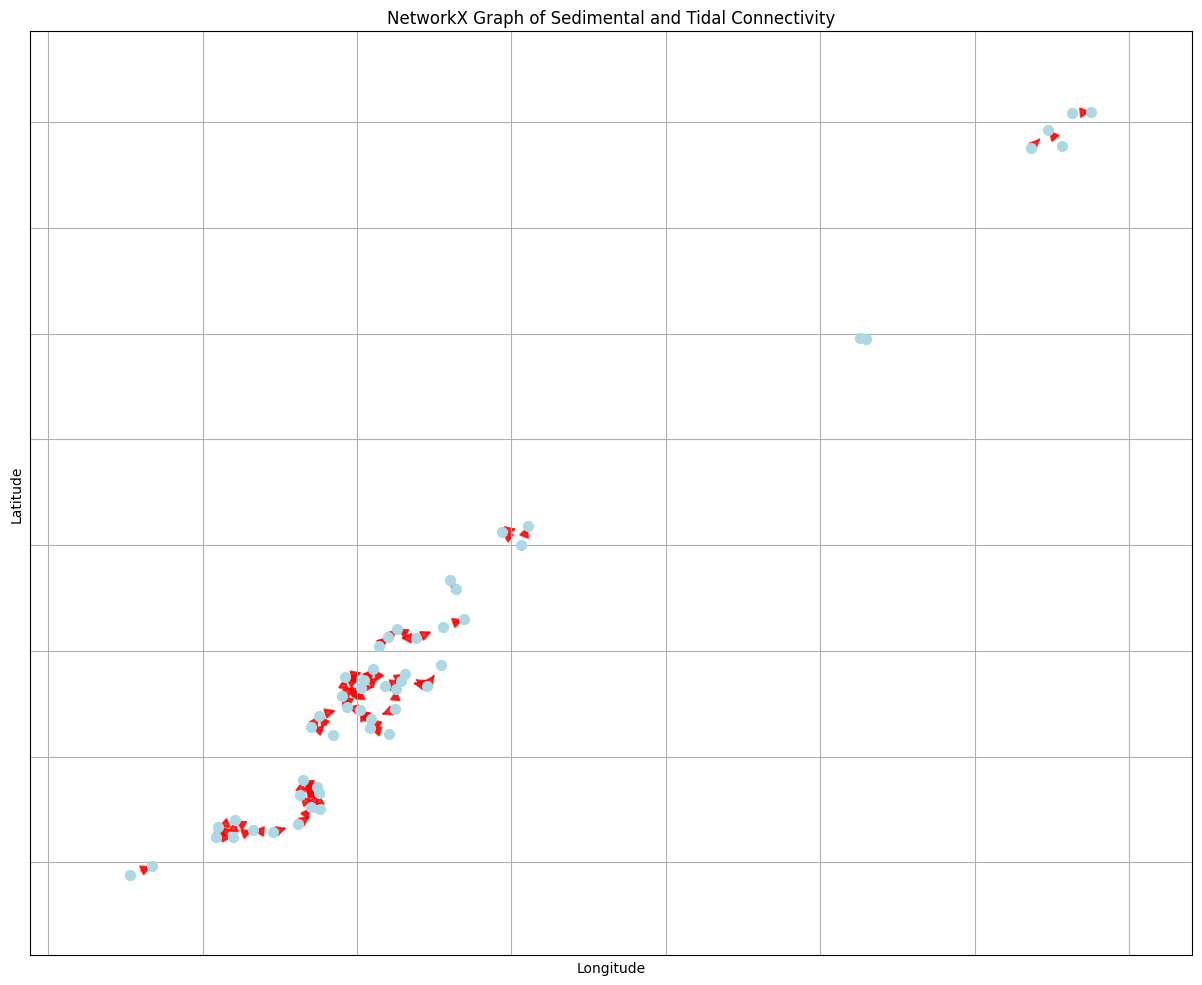

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 12)) # Increase figure size for better visibility

# Draw nodes with a smaller size
nx.draw_networkx_nodes(G, node_positions, node_color='lightblue', node_size=50) # Reduced node_size

# Draw sedimental edges (undirected, typically shown as bidirectional in DiGraph)
sedimental_edges = [(u, v) for u, v, data in G.edges(data=True) if data['type'] == 'sedimental']
nx.draw_networkx_edges(G, node_positions, edgelist=sedimental_edges, edge_color='green', alpha=0.8, width=2.0) # Increased width

# Draw tidal edges (directed) with a distinct color and increased width
tidal_edges = [(u, v) for u, v, data in G.edges(data=True) if data['type'] == 'tidal']
nx.draw_networkx_edges(G, node_positions, edgelist=tidal_edges, edge_color='red', alpha=0.8, arrowsize=15, width=1.5) # Increased width and arrowsize

# Draw labels (optional, can clutter if too many nodes)
# nx.draw_networkx_labels(G, node_positions, font_size=8)

plt.title('NetworkX Graph of Sedimental and Tidal Connectivity')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

# GRAPH Visual on World Map

In [ ]:
import pandas as pd

final_graph_csv_path = '/content/graph_edges.csv'
final_graph_df_loaded = pd.read_csv(final_graph_csv_path)

print(f"Contents of {final_graph_csv_path}:")
print(final_graph_df_loaded.head())

Contents of /content/graph_edges.csv:
   source  target   edge_type  distance_km  source_latitude  source_longitude  \
0    19.0    20.0  sedimental     1.468261        24.300814         54.439904   
1    25.0    26.0  sedimental     1.445149        24.330262         54.438044   
2    40.0    42.0  sedimental     1.899410        24.527530         54.563552   
3    40.0    46.0  sedimental     1.868109        24.527530         54.563552   
4    41.0    44.0  sedimental     1.831465        24.529430         54.506097   

   target_latitude  target_longitude  
0        24.303727         54.425772  
1        24.342864         54.434558  
2        24.533467         54.545946  
3        24.542729         54.571421  
4        24.545198         54.511327  


In [ ]:
import numpy as np
import folium

# Get all unique latitudes and longitudes from source and target nodes
all_lats = pd.concat([final_graph_df_loaded['source_latitude'], final_graph_df_loaded['target_latitude']])
all_lons = pd.concat([final_graph_df_loaded['source_longitude'], final_graph_df_loaded['target_longitude']])

# Calculate the central latitude and longitude
central_lat = all_lats.mean()
central_lon = all_lons.mean()

print(f"Central latitude for map: {central_lat:.4f}")
print(f"Central longitude for map: {central_lon:.4f}")


Central latitude for map: 24.5152
Central longitude for map: 54.5396


In [ ]:
import folium

# Create a Folium map centered at the calculated coordinates
m = folium.Map(location=[central_lat, central_lon], zoom_start=9)

# Add patches as polygons to the map
for idx, row in clustered_patches_with_polygons_dbscan_df.iterrows():
    patch_id = row['patch_id']
    polygon_coords = row['polygon_coords']
    total_absorption = row['monthly_absorption_tCO2e_ha']

    # Folium expects coordinates in [latitude, longitude] format
    # The stored polygon_coords are often in (longitude, latitude) from shapely.convex_hull.exterior.coords
    # We need to ensure they are [lat, lon]
    folium_coords_for_polygon = [[p[0], p[1]] for p in polygon_coords] # Assuming polygon_coords are already [lat,lon]

    # Only add polygon if it has valid coordinates
    if folium_coords_for_polygon:
        # Create a tooltip for the polygon
        tooltip_content_polygon = f"Patch ID: {patch_id}<br>Total Monthly Absorption: {total_absorption:.2f} tCO2e/ha"

        # Add the polygon to the map
        folium.Polygon(
            locations=folium_coords_for_polygon,
            color='blue', # Color for the polygon boundary
            fill=True,
            fill_color='cyan', # Fill color for the polygon
            fill_opacity=0.3,
            tooltip=tooltip_content_polygon
        ).add_to(m)

# Add edges to the map (existing logic)
for idx, row in final_graph_df_loaded.iterrows():
    start_coords = [row['source_latitude'], row['source_longitude']]
    end_coords = [row['target_latitude'], row['target_longitude']]

    # Determine edge color and style based on type
    if row['edge_type'] == 'sedimental':
        line_color = 'green'
        dash_array = '1, 1' # Solid line
        weight = 2
    elif row['edge_type'] == 'tidal':
        line_color = 'red'
        dash_array = '5, 5' # Dashed line for tidal
        weight = 1.5
    else:
        line_color = 'gray'
        dash_array = '1, 1'
        weight = 1

    # Create a tooltip for the edge
    edge_tooltip = f"Edge Type: {row['edge_type'].capitalize()}<br>Distance: {row['distance_km']:.2f} km"

    # Add line to the map
    folium.PolyLine(
        locations=[start_coords, end_coords],
        color=line_color,
        weight=weight,
        tooltip=edge_tooltip,
        dash_array=dash_array
    ).add_to(m)

print("Folium map created with patches as polygons and edges.")
m

Folium map created with patches as polygons and edges.


# Verifying Data Available

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/STAGE 1/clustered_patches_with_polygons_dbscan.csv')
df.head()

,patch_id,monthly_absorption_tCO2e_ha,polygon_coords
0,0,1199.485735,"[[23.95947323405253, 52.0624604136], [23.95947..."
1,1,1339.718000,"[[23.982271489212007, 51.9181264344], [23.9803..."
2,2,253.738441,"[[24.115261310975608, 52.832241636], [24.12286..."
3,3,1093.134379,"[[24.12856029315197, 53.909516988], [24.130460..."
4,4,3232.476798,"[[24.17605665806754, 54.1458900264], [24.16085..."


In [ ]:
df1=pd.read_csv('/content/drive/MyDrive/STAGE 1/graph_edges.csv')
df1.head()

,source,target,edge_type,distance_km,source_latitude,source_longitude,target_latitude,target_longitude
0,19.0,20.0,sedimental,1.468261,24.300814,54.439904,24.303727,54.425772
1,25.0,26.0,sedimental,1.445149,24.330262,54.438044,24.342864,54.434558
2,40.0,42.0,sedimental,1.899410,24.527530,54.563552,24.533467,54.545946
3,40.0,46.0,sedimental,1.868109,24.527530,54.563552,24.542729,54.571421
4,41.0,44.0,sedimental,1.831465,24.529430,54.506097,24.545198,54.511327


In [ ]:
df1.shape

(79, 8)

In [ ]:
df1.rename(columns={'source': 'source_patch_id', 'target': 'destination_patch_id'}, inplace=True)
df1['source_patch_id'] = df1['source_patch_id'].astype(int)
df1['destination_patch_id'] = df1['destination_patch_id'].astype(int)
df1.head()

,source_patch_id,destination_patch_id,edge_type,distance_km,source_latitude,source_longitude,target_latitude,target_longitude
0,19,20,sedimental,1.468261,24.300814,54.439904,24.303727,54.425772
1,25,26,sedimental,1.445149,24.330262,54.438044,24.342864,54.434558
2,40,42,sedimental,1.899410,24.527530,54.563552,24.533467,54.545946
3,40,46,sedimental,1.868109,24.527530,54.563552,24.542729,54.571421
4,41,44,sedimental,1.831465,24.529430,54.506097,24.545198,54.511327


In [ ]:
df1.to_csv('/content/drive/MyDrive/STAGE 1/graph_edges.csv',index=False)

In [ ]:
df2=pd.read_csv('/content/drive/MyDrive/STAGE 1/graph_edges.csv')
df2.head()

,source_patch_id,destination_patch_id,edge_type,distance_km,source_latitude,source_longitude,target_latitude,target_longitude
0,19,20,sedimental,1.468261,24.300814,54.439904,24.303727,54.425772
1,25,26,sedimental,1.445149,24.330262,54.438044,24.342864,54.434558
2,40,42,sedimental,1.899410,24.527530,54.563552,24.533467,54.545946
3,40,46,sedimental,1.868109,24.527530,54.563552,24.542729,54.571421
4,41,44,sedimental,1.831465,24.529430,54.506097,24.545198,54.511327


In [ ]:

df3=pd.read_csv('/content/drive/MyDrive/STAGE 1/S1_S2_GEDI_New_UAE_Imputed_Monthly.csv')
df3.drop(['Unnamed: 0'],axis=1,inplace=True)

df3.to_csv('/content/drive/MyDrive/STAGE 1/S1_S2_GEDI_New_UAE_Imputed_Monthly.csv',index=False)
df4=pd.read_csv('/content/drive/MyDrive/STAGE 1/S1_S2_GEDI_New_UAE_Imputed_Monthly.csv')
df4.columns

Index(['latitude', 'longitude', 'VV_backscatter', 'VH_backscatter',
       'VV_coherence', 'VH_coherence', 'date', 'B1', 'B2', 'B3', 'B4', 'B5',
       'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'SCL', 'NDVI', 'NDWI',
       'NDSI', 'Moisture_index', 'SWIR', 'Scene_classification_map',
       'False_color', 'False_color_urban', 'Highlight_Optimized_Natural_Color',
       'True_color', 'GEDI_canopy_height_rh100', 'GEDI_canopy_height_rh98',
       'GEDI_canopy_height_rh92', 'GEDI_elevation_lowestmode', 'GEDI_PAI',
       'GEDI_FHD', 'GEDI_FCOVER', 'GEDI_biomass_Mg_ha', 'carbon_stock_MgC_ha',
       'carbon_stock_tCO2e_ha', 'monthly_absorption_MgC_ha',
       'monthly_absorption_tCO2e_ha'],
      dtype='object')

# ADD Patch ID to Main DF

In [ ]:
!pip install shapely

In [ ]:
import pandas as pd
import ast # To safely evaluate string representations of lists
from shapely.geometry import Polygon

# Load the clustered patches CSV
clustered_patches_df = pd.read_csv('/content/drive/MyDrive/STAGE 1/clustered_patches_with_polygons_dbscan.csv')

# Convert the 'polygon_coords' string column into actual list of coordinates
# Then create shapely Polygon objects
clustered_patches_df['polygon_coords'] = clustered_patches_df['polygon_coords'].apply(ast.literal_eval)
clustered_patches_df['polygon'] = clustered_patches_df['polygon_coords'].apply(lambda x: Polygon(x) if x else None)

print("clustered_patches_with_polygons_dbscan.csv loaded and 'polygon_coords' parsed into shapely Polygon objects.")
print(clustered_patches_df.head())
print(clustered_patches_df.info())

clustered_patches_with_polygons_dbscan.csv loaded and 'polygon_coords' parsed into shapely Polygon objects.
   patch_id  monthly_absorption_tCO2e_ha  \
0         0                  1199.485735   
1         1                  1339.718000   
2         2                   253.738441   
3         3                  1093.134379   
4         4                  3232.476798   

                                      polygon_coords  \
0  [[23.95947323405253, 52.0624604136], [23.95947...   
1  [[23.982271489212007, 51.9181264344], [23.9803...   
2  [[24.115261310975608, 52.832241636], [24.12286...   
3  [[24.12856029315197, 53.909516988], [24.130460...   
4  [[24.17605665806754, 54.1458900264], [24.16085...   

                                             polygon  
0  POLYGON ((23.95947323405253 52.0624604136, 23....  
1  POLYGON ((23.982271489212007 51.9181264344, 23...  
2  POLYGON ((24.115261310975608 52.832241636, 24....  
3  POLYGON ((24.12856029315197 53.909516988, 24.1...  
4  POLYGON ((24

In [ ]:
from shapely.geometry import Point

# Ensure df4 is loaded (from previous steps)
# df4 = pd.read_csv('/content/drive/MyDrive/STAGE 1/S1_S2_GEDI_New_UAE_Imputed_Monthly.csv')
# df4.drop(['Unnamed: 0'], axis=1, inplace=True, errors='ignore') # Ensure no 'Unnamed: 0' column

# Create a function to find the patch_id for a given point
def get_patch_id(row, patches_df):
    point = Point(row['latitude'], row['longitude']) # Create a shapely Point from current row's coordinates
    for idx, patch_row in patches_df.iterrows():
        if patch_row['polygon'] is not None and point.within(patch_row['polygon']):
            return patch_row['patch_id']
    return -1  # Return -1 if no polygon contains the point

print("Applying patch_id assignment to df4. This may take some time...")

# Apply the function to each row of df4 to assign patch_id
df4['patch_id'] = df4.apply(lambda row: get_patch_id(row, clustered_patches_df), axis=1)

print("Patch IDs assigned to df4.")
print(df4.head())
print(df4.info())


Applying patch_id assignment to df4. This may take some time...
Patch IDs assigned to df4.
    latitude  longitude  VV_backscatter  VH_backscatter  VV_coherence  \
0  22.791063  54.246296      -24.314251      -31.478721      0.003703   
1  22.791063  54.246296      -25.507535      -30.963398      0.002819   
2  22.791063  54.246296      -25.626493      -31.186509      0.002737   
3  22.791063  54.246296      -23.189345      -31.998171      0.004816   
4  22.791063  54.246296      -22.832819      -25.969246      0.005209   

   VH_coherence        date     B1      B2      B3  ...  GEDI_PAI  GEDI_FHD  \
0      0.000711  2021-01-01  755.0  1004.5  1856.5  ...  0.275530  3.111608   
1      0.000801  2021-02-01  743.0  1055.0  1854.0  ...  0.035450  1.304219   
2      0.000761  2021-03-01  693.5  1009.0  1882.0  ...  0.166437  1.684900   
3      0.000642  2021-04-01  733.0  1026.0  1736.0  ...  0.016584  1.592468   
4      0.002530  2021-05-01  756.5  1032.0  1804.0  ...  0.023738  1.215489

In [ ]:
df4['coordinate'] = list(zip(df4['latitude'], df4['longitude']))
df4.drop(columns=['latitude', 'longitude'], inplace=True)

print("Original 'latitude' and 'longitude' columns dropped, and new 'coordinate' column created.")
print(df4.head())
print(df4.info())

Original 'latitude' and 'longitude' columns dropped, and new 'coordinate' column created.
   VV_backscatter  VH_backscatter  VV_coherence  VH_coherence        date  \
0      -24.314251      -31.478721      0.003703      0.000711  2021-01-01   
1      -25.507535      -30.963398      0.002819      0.000801  2021-02-01   
2      -25.626493      -31.186509      0.002737      0.000761  2021-03-01   
3      -23.189345      -31.998171      0.004816      0.000642  2021-04-01   
4      -22.832819      -25.969246      0.005209      0.002530  2021-05-01   

      B1      B2      B3      B4      B5  ...  GEDI_PAI  GEDI_FHD  \
0  755.0  1004.5  1856.5  3854.0  4412.0  ...  0.275530  3.111608   
1  743.0  1055.0  1854.0  3866.0  4468.5  ...  0.035450  1.304219   
2  693.5  1009.0  1882.0  3948.0  4562.5  ...  0.166437  1.684900   
3  733.0  1026.0  1736.0  3804.0  4423.0  ...  0.016584  1.592468   
4  756.5  1032.0  1804.0  3972.0  4589.0  ...  0.023738  1.215489   

   GEDI_FCOVER  GEDI_biomass_Mg_

# Specified Files for Each Patch

In [ ]:
import pandas as pd
import os

# Load the DataFrame
df_path = '/content/drive/MyDrive/STAGE 3/S1_S2_GEDI_New_UAE_Imputed_patch_Monthly.csv'
df = pd.read_csv(df_path)

# Get unique patch_ids, excluding -1 (noise points)
unique_patch_ids = df['patch_id'].unique()
valid_patch_ids = [pid for pid in unique_patch_ids if pid != -1]

output_dir = '/content/drive/MyDrive/STAGE 3/'

print(f"Found {len(valid_patch_ids)} valid patch IDs to process.")

for patch_id in valid_patch_ids:
    # Filter DataFrame for the current patch_id
    patch_df = df[df['patch_id'] == patch_id].copy()

    # Construct the output filename
    output_filename = f"Patch_{int(patch_id)}_Satelite.csv"
    output_filepath = os.path.join(output_dir, output_filename)

    # Save the filtered DataFrame to CSV
    patch_df.to_csv(output_filepath, index=False)

    print(f"Saved {output_filename} with {len(patch_df)} rows.")

print("Finished creating individual CSV files for each patch.")

Found 68 valid patch IDs to process.
Saved Patch_0_Satelite.csv with 305 rows.
Saved Patch_1_Satelite.csv with 183 rows.
Saved Patch_3_Satelite.csv with 366 rows.
Saved Patch_4_Satelite.csv with 1891 rows.
Saved Patch_5_Satelite.csv with 122 rows.
Saved Patch_6_Satelite.csv with 61 rows.
Saved Patch_7_Satelite.csv with 61 rows.
Saved Patch_8_Satelite.csv with 3416 rows.
Saved Patch_9_Satelite.csv with 427 rows.
Saved Patch_10_Satelite.csv with 244 rows.
Saved Patch_11_Satelite.csv with 122 rows.
Saved Patch_13_Satelite.csv with 671 rows.
Saved Patch_12_Satelite.csv with 671 rows.
Saved Patch_14_Satelite.csv with 4453 rows.
Saved Patch_15_Satelite.csv with 305 rows.
Saved Patch_16_Satelite.csv with 122 rows.
Saved Patch_17_Satelite.csv with 122 rows.
Saved Patch_18_Satelite.csv with 549 rows.
Saved Patch_19_Satelite.csv with 1769 rows.
Saved Patch_21_Satelite.csv with 61 rows.
Saved Patch_20_Satelite.csv with 122 rows.
Saved Patch_22_Satelite.csv with 183 rows.
Saved Patch_23_Satelite.c